# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 51     |  |
| :-------------|:-------------|
| Kimi Hekmat| 6534759 |
| Frank de Kogel| 6582737 |
| Student naam 3| Student Studienummer 3 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Frank', 'Kimi']

## Opdracht 1: Planning.

| Planning Groep: 51     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1 | 12:30 |
| Mijlpaal 2 | 16:30 |
| groep aanwezig 1| 13:30 |
| groep aanwezig 2| 16:15 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| 16:00-16:15 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [51]
Bij onze kalibratieopstelling meten we enkel de afstand heen (er is geen afstand terug)
<img src="kalibratie_echo.jpeg" width="400">

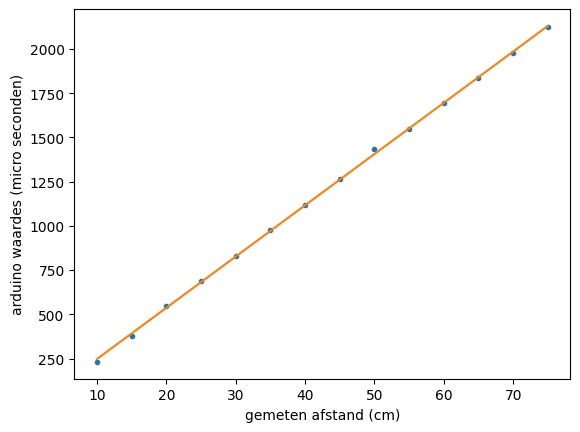

[ 28.97450549 -42.48791209]


In [3]:
# verwerk hier jullie kalibratiemetingen

fysiek = np.array([10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75]) # afstanden in centimeters (voorkant vericale platen)
arduino = np.array([231, 378, 549, 687, 830, 975, 1119, 1266, 1433, 1548, 1693, 1837, 1977, 2122]) # Meettijden in microseconden

def fit(x, a, b):
    return a*x + b

vals, covs = curve_fit(fit, fysiek, arduino)
xtest = np.linspace(np.min(fysiek), np.max(fysiek), 500)
ytest = fit(xtest, *vals)

plt.figure()
plt.plot(fysiek, arduino, '.', label = 'meetdata')
plt.plot(xtest, ytest, label = 'fit')
plt.xlabel('gemeten afstand (cm)')
plt.ylabel('arduino waardes (micro seconden)')
plt.show()

print(vals)

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  41.6
1   0  30   0  20  41.1
2  40   0  30   0  39.9
3  30   0  20   0  40.3


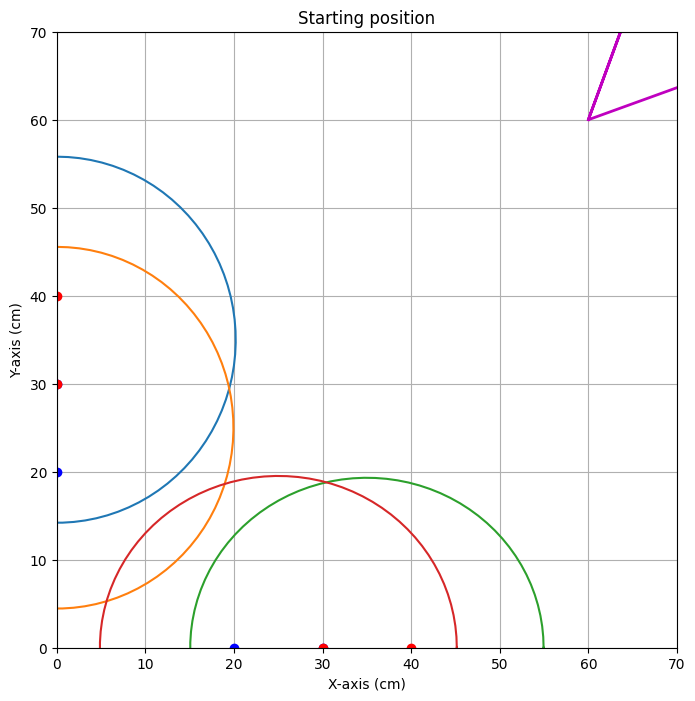


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=101.230


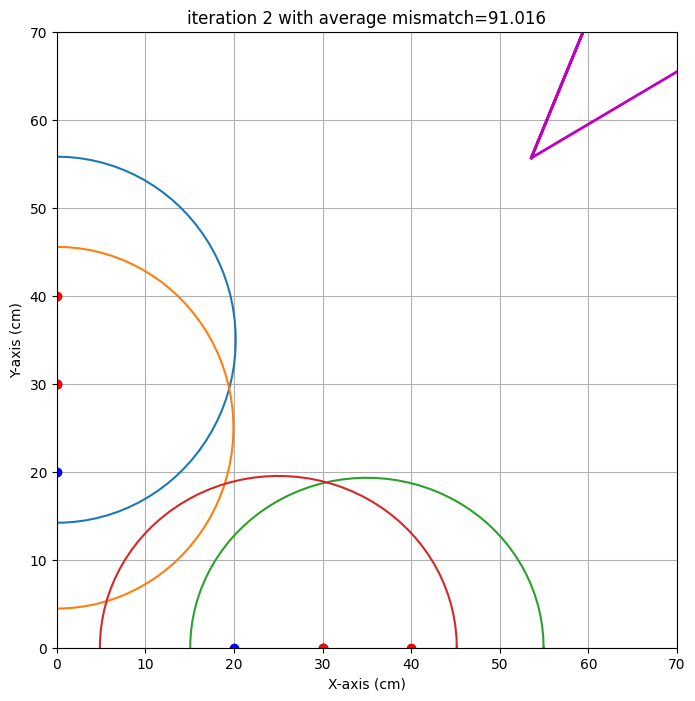

end iteration 2 with average mismatch=91.016


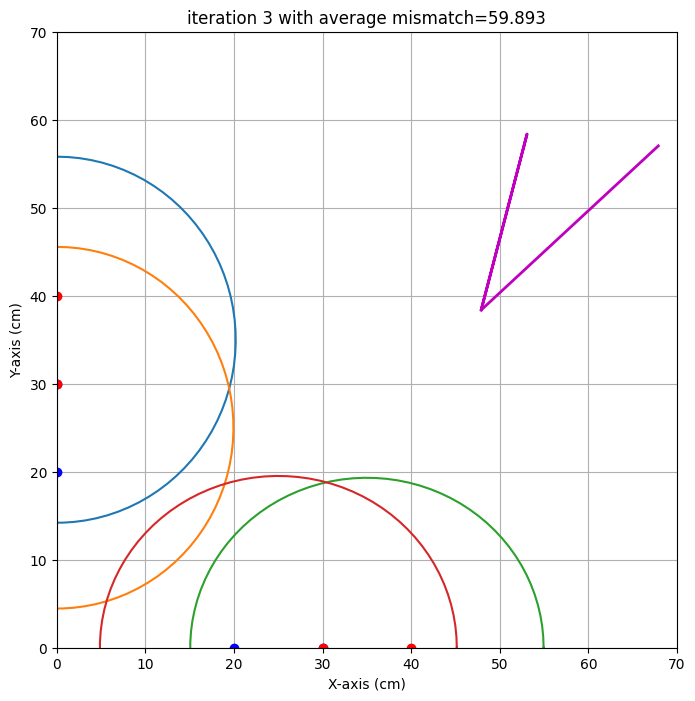

end iteration 3 with average mismatch=59.893


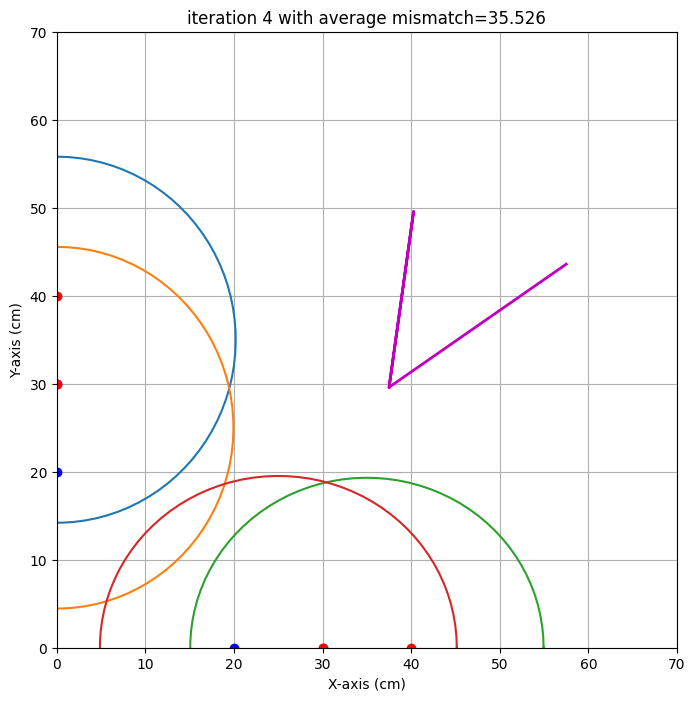

end iteration 4 with average mismatch=35.526


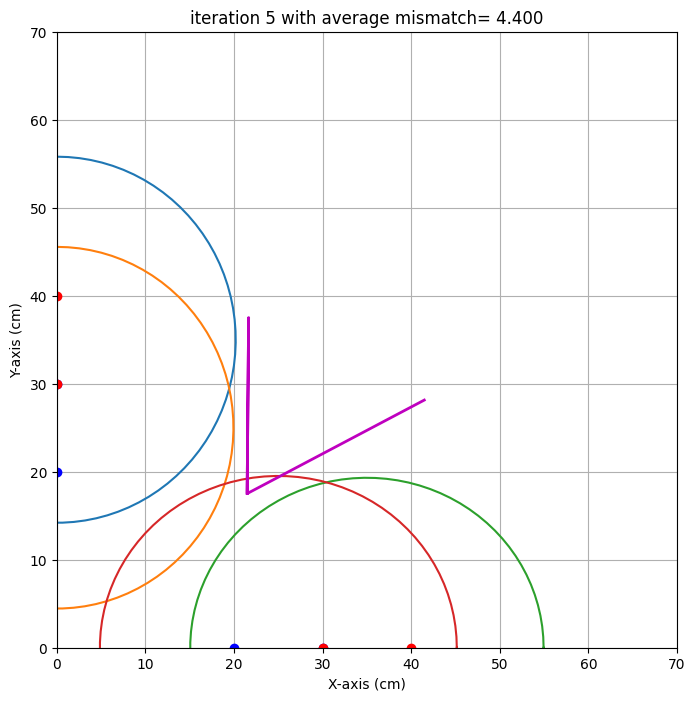

end iteration 5 with average mismatch= 4.400


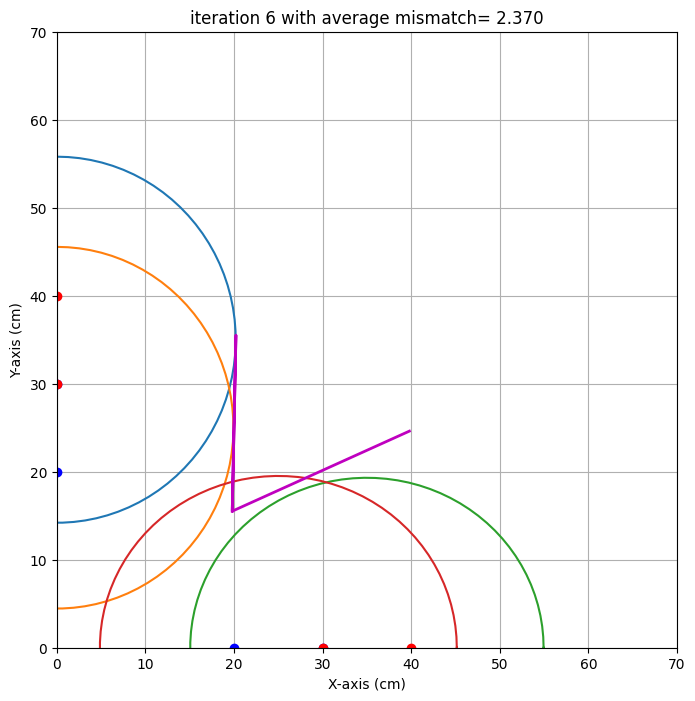

end iteration 6 with average mismatch= 2.370
end iteration 7 with average mismatch= 2.365
end iteration 8 with average mismatch= 2.271
end iteration 9 with average mismatch= 2.207


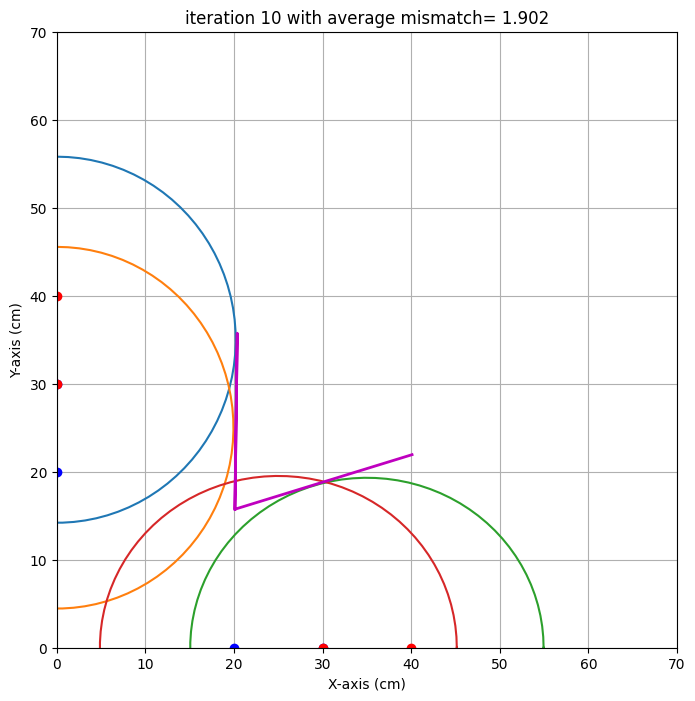

end iteration 10 with average mismatch= 1.902
end iteration 11 with average mismatch= 1.824
end iteration 12 with average mismatch= 1.771
end iteration 13 with average mismatch= 1.764
end iteration 14 with average mismatch= 1.674
end iteration 15 with average mismatch= 1.559
end iteration 16 with average mismatch= 1.539
end iteration 17 with average mismatch= 1.539
end iteration 18 with average mismatch= 1.497


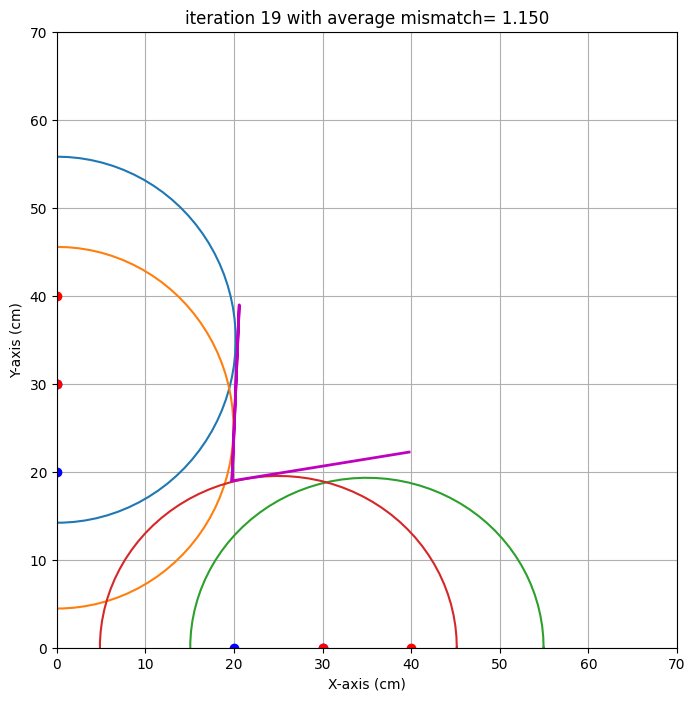

end iteration 19 with average mismatch= 1.150
end iteration 20 with average mismatch= 1.066
end iteration 21 with average mismatch= 1.052


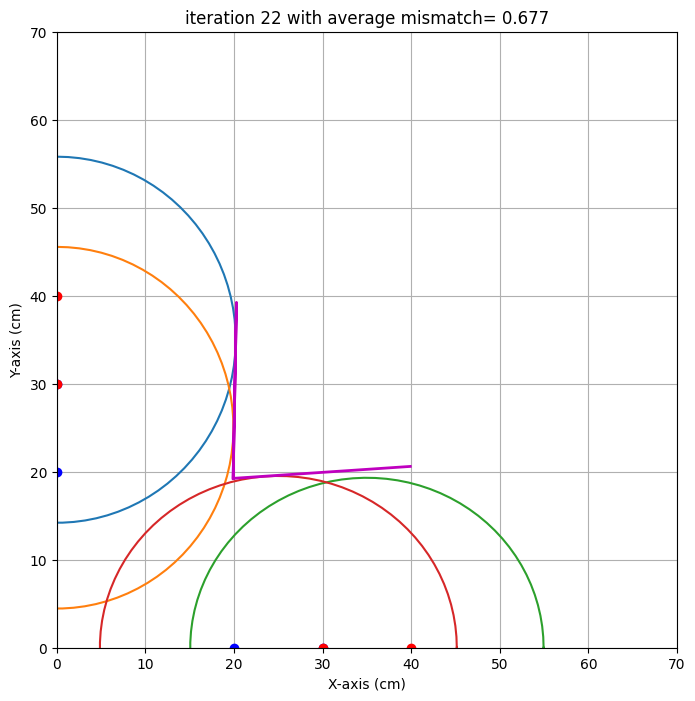

end iteration 22 with average mismatch= 0.677
end iteration 23 with average mismatch= 0.674


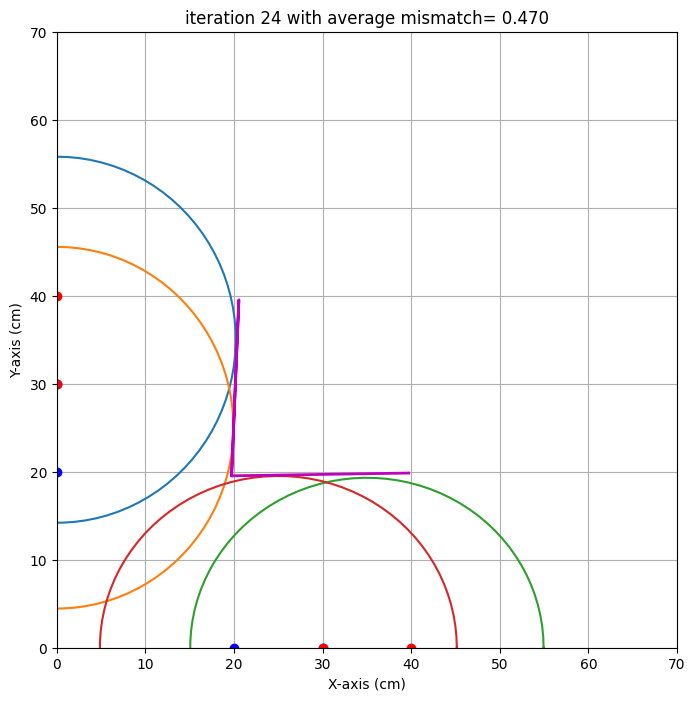

end iteration 24 with average mismatch= 0.470


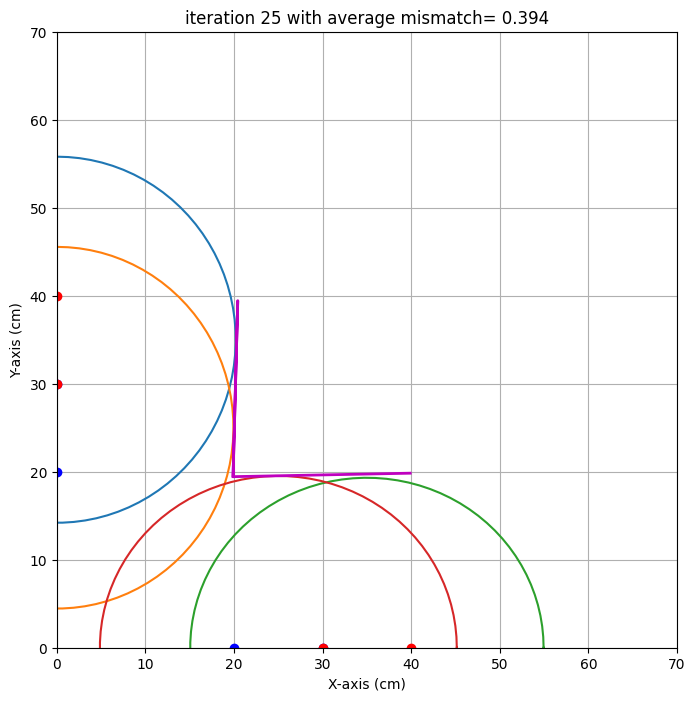

end iteration 25 with average mismatch= 0.394
end iteration 26 with average mismatch= 0.359
end iteration 27 with average mismatch= 0.348
end iteration 28 with average mismatch= 0.347


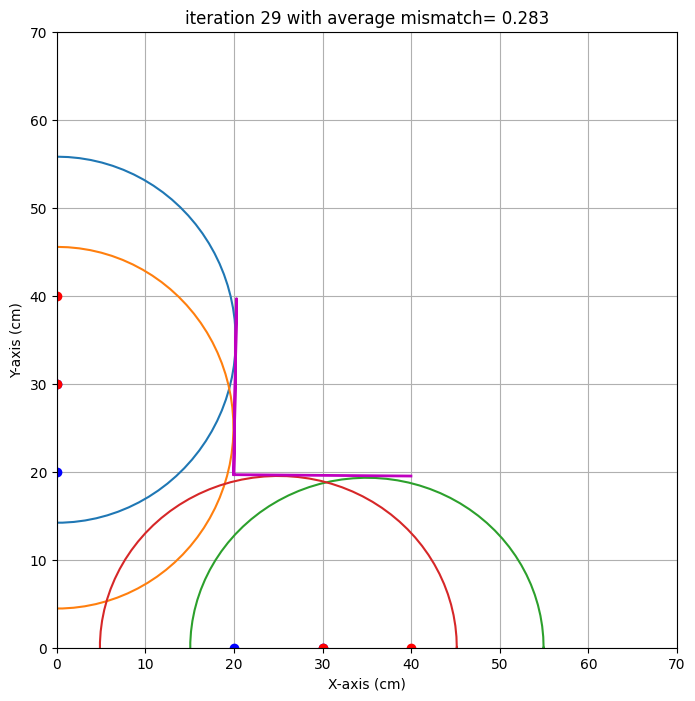

end iteration 29 with average mismatch= 0.283
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.260
###############################################################################
end of iteration  30
Best alpha=  -0.45 with uncertainty=   1.05
Best beta =   0.86 with uncertainty=   1.39
Best x0   =  19.95 with uncertainty=   0.52
Best y0   =  19.64 with uncertainty=   0.15
###############################################################################


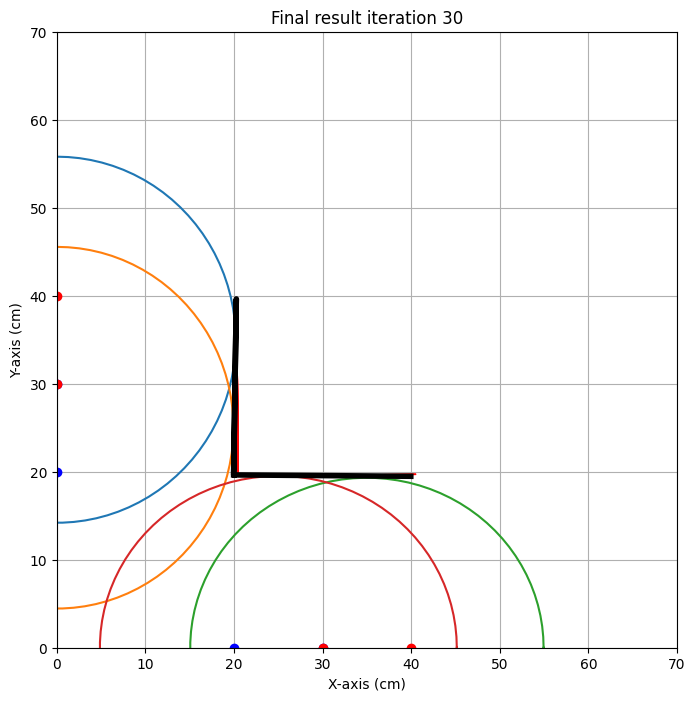

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,41.6],
    [0,30,0,20,41.1],
    #[0,10,0,20,180], deze meting was onrealistisch, dus uitgecomment
    [40,0,30,0,39.9],
    [30,0,20,0,40.3],
    #[10,0,20,0,199.98], deze meting ongeldig voor dezelfde reden, hij pakt de hoek
    #[10,0,0,10,187.63], deze meting ongeldig, nam de hoek mee    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 20.0 cm met een standaardafwijking van 0.5 cm 
y0: 19.6 cm met een standaardafwijking van 0.1 cm 
alpha: -0.4 graden met een standaardafwijking van 1.1 graad 
beta: 0.9 graden met een standaardafwijking van 1.4 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Kimi]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="iteratie0Kimi.jpeg" width="400">

#### algoritme [Frank]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="Iteratie0Frank.jpeg" width="400">

geen derde student

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':35,
           'y0':32,#zelf aanvullen,
           'alpha' :30, #zelf aanvullen,
           'beta' : 0,#zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Frank' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [45,0,70,0,69.8],
    [45,0,20,0,66.8],
    #[0,45,0,70,x]
    [0,45,0,20,63.3],
    [0,60,0,20,71.6],
    [70,0,30,0,71.4]
    ]),
    'Kimi' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[30,0,40,0,x],
    [50,0,60,0,84.2],
    [0,30,0,40,71.4],
    #[0,35,0,45,x],
    #[0,40,0,50,x],
    [0,35,0,45,67.9],
    [0,40,0,50,65.5]
    ])
      }

## Opdracht 7: Evaluatie.

Frank
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  45   0  70   0  69.8
1  45   0  20   0  66.8
2   0  45   0  20  63.3
3   0  60   0  20  71.6
4  70   0  30   0  71.4


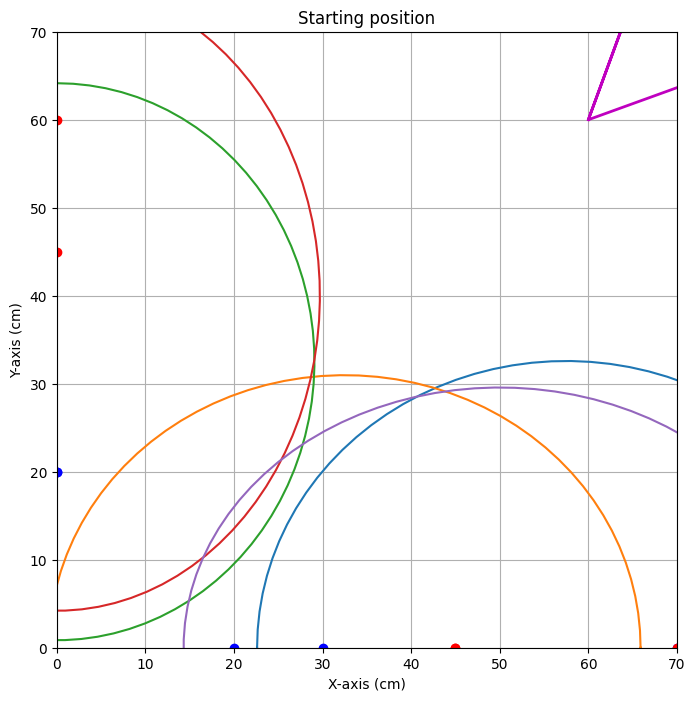


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=68.630


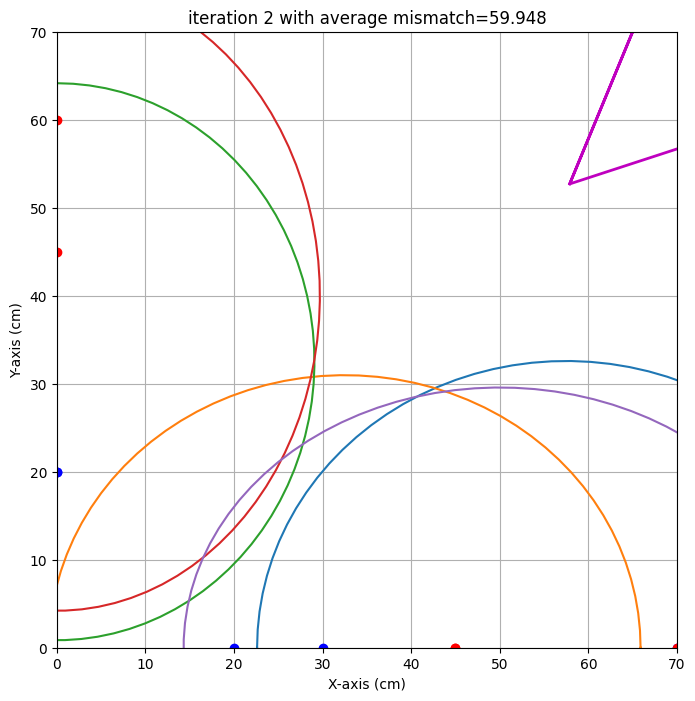

end iteration 2 with average mismatch=59.948


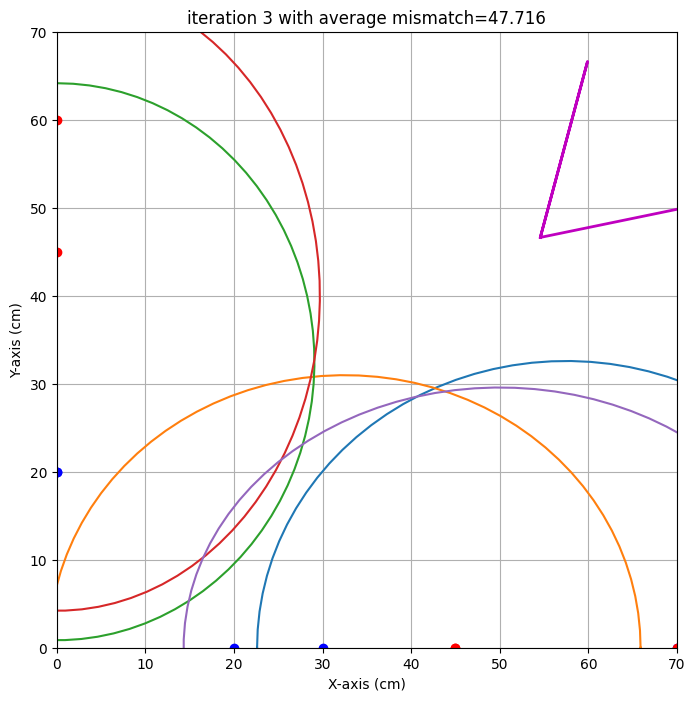

end iteration 3 with average mismatch=47.716


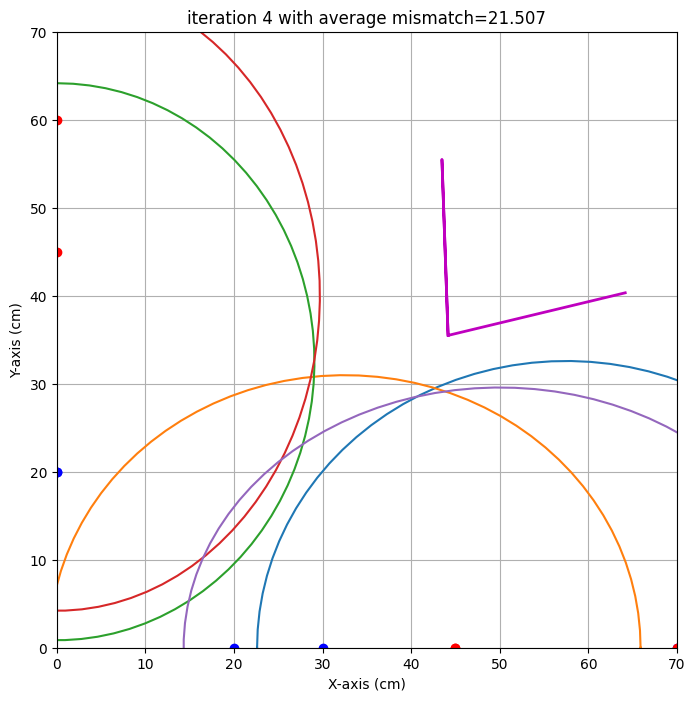

end iteration 4 with average mismatch=21.507


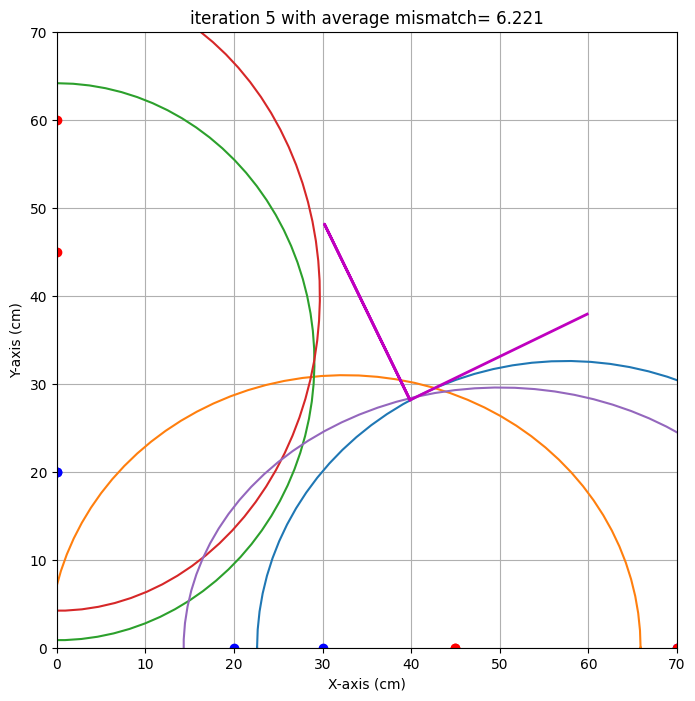

end iteration 5 with average mismatch= 6.221


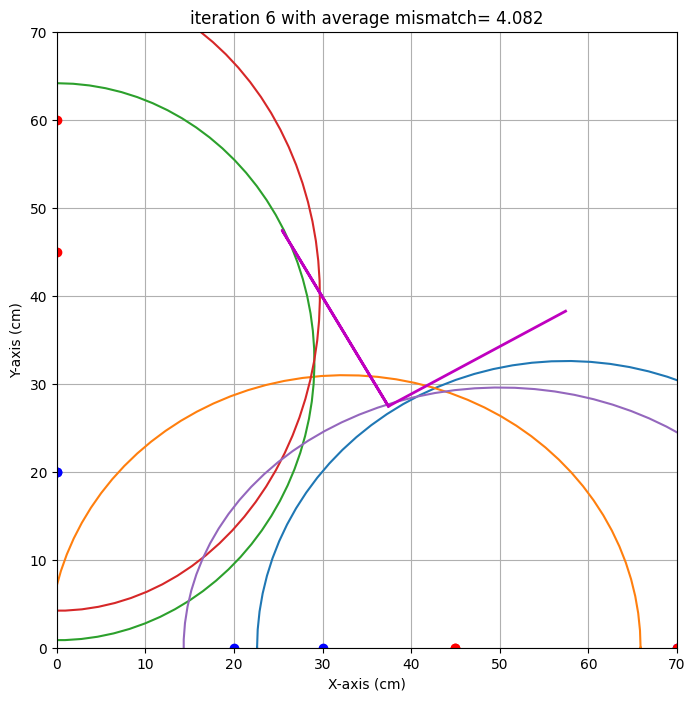

end iteration 6 with average mismatch= 4.082
end iteration 7 with average mismatch= 3.946
end iteration 8 with average mismatch= 3.934


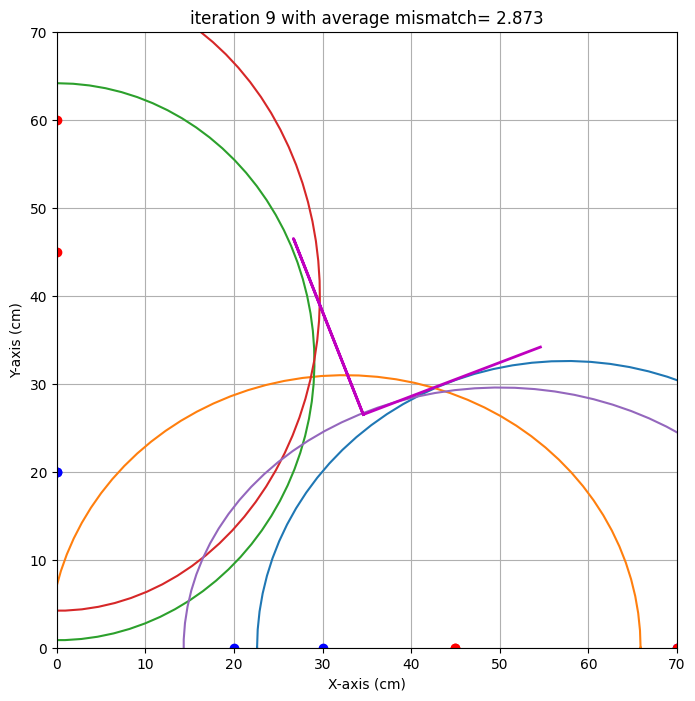

end iteration 9 with average mismatch= 2.873


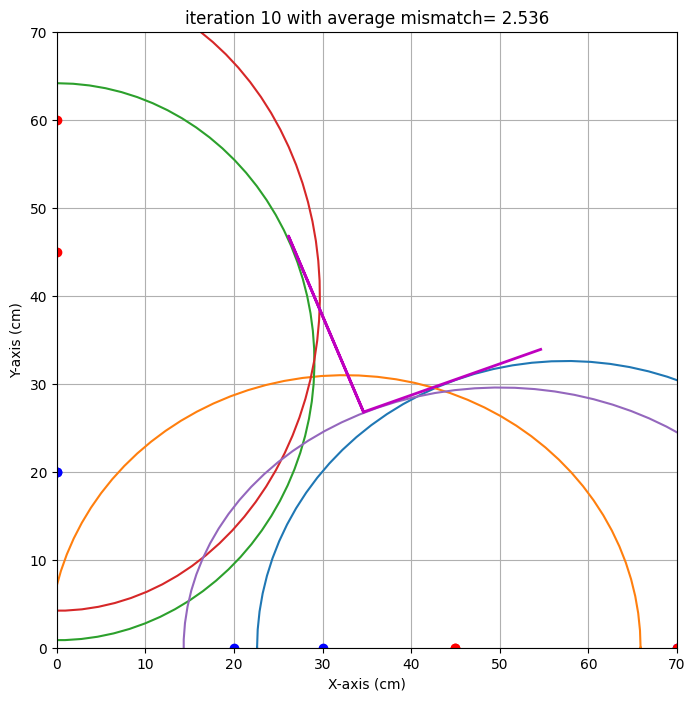

end iteration 10 with average mismatch= 2.536
end iteration 11 with average mismatch= 2.480
end iteration 12 with average mismatch= 2.477
end iteration 13 with average mismatch= 2.451
end iteration 14 with average mismatch= 2.436
end iteration 15 with average mismatch= 2.433
end iteration 16 with average mismatch= 2.424
end iteration 17 with average mismatch= 2.424
end iteration 18 with average mismatch= 2.403
end iteration 19 with average mismatch= 2.187
end iteration 20 with average mismatch= 2.175


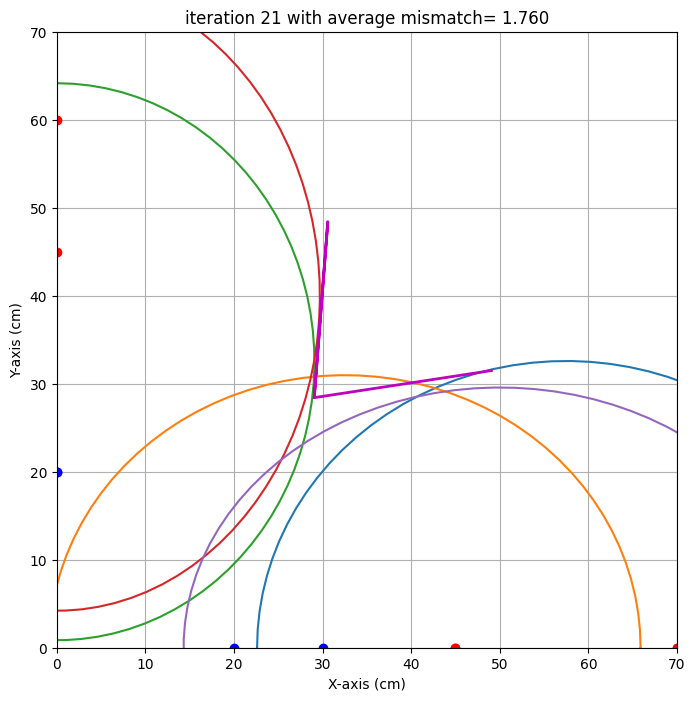

end iteration 21 with average mismatch= 1.760
end iteration 22 with average mismatch= 1.698
end iteration 23 with average mismatch= 1.644
end iteration 24 with average mismatch= 1.626
end iteration 25 with average mismatch= 1.622
end iteration 26 with average mismatch= 1.622
end iteration 27 with average mismatch= 1.622
end iteration 28 with average mismatch= 1.622
end iteration 29 with average mismatch= 1.622
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 1.474
###############################################################################
end of iteration  30
Best alpha=   1.28 with uncertainty=  13.31
Best beta =   1.50 with uncertainty=   6.56
Best x0   =  29.34 with uncertainty=   1.32
Best y0   =  30.91 with uncertainty=   4.48
###############################################################################


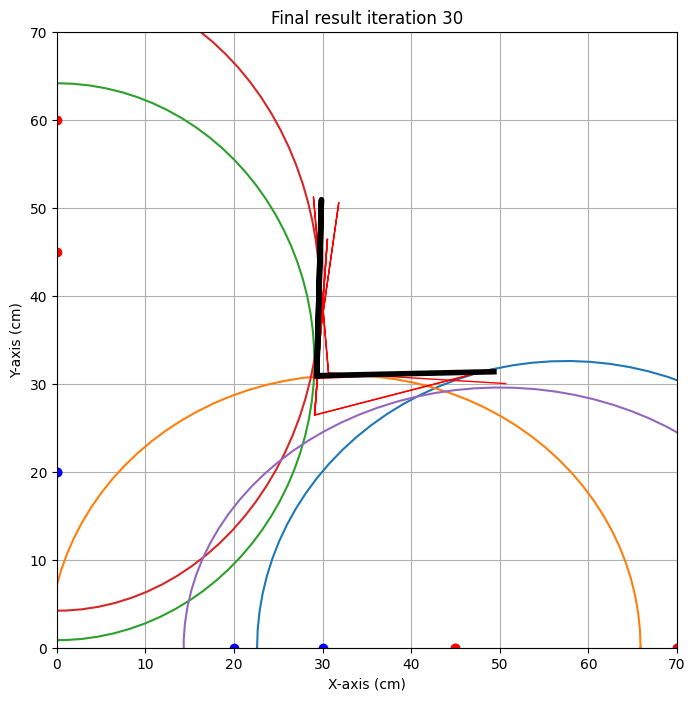

{'alpha': np.float64(1.283513721665821), 'alpha_eps': np.float64(13.305133017516521), 'beta': np.float64(1.5038194392327169), 'beta_eps': np.float64(6.564687475349717), 'x0': np.float64(29.34034398701847), 'x0_eps': np.float64(1.322248462496031), 'y0': np.float64(30.91330688596105), 'y0_eps': np.float64(4.476034244276242)}
Kimi
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  50   0  60   0  84.2
1   0  30   0  40  71.4
2   0  35   0  45  67.9
3   0  40   0  50  65.5


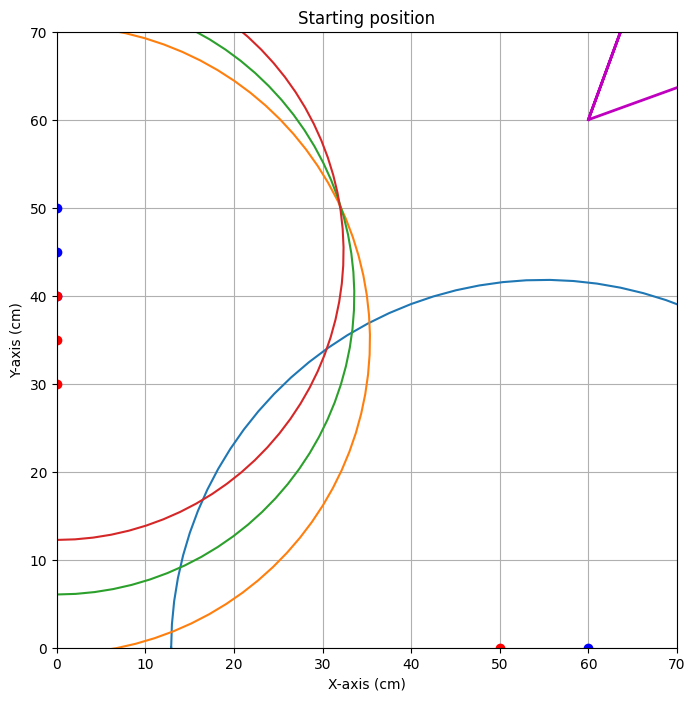


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=58.813


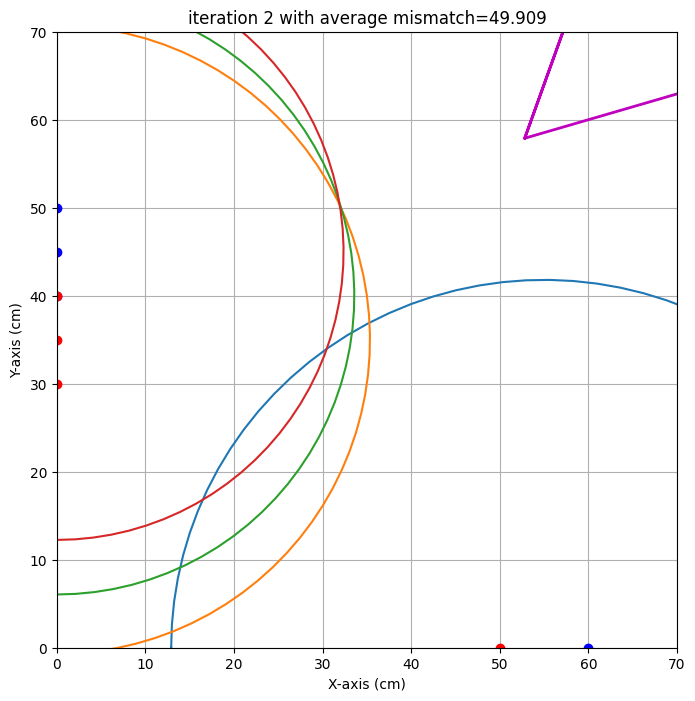

end iteration 2 with average mismatch=49.909


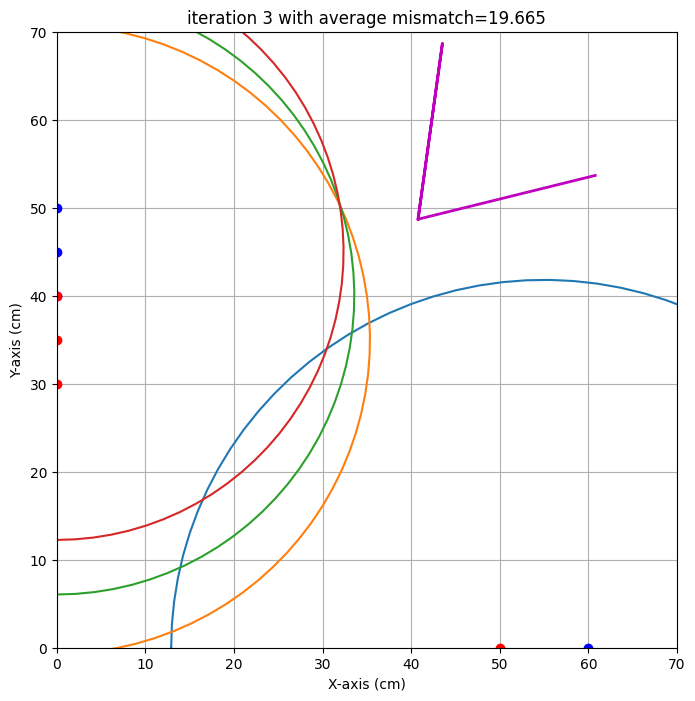

end iteration 3 with average mismatch=19.665


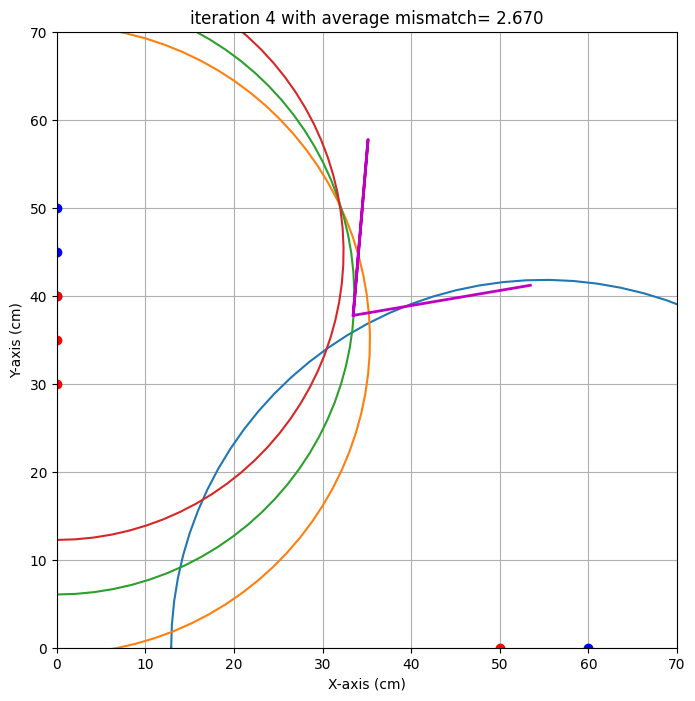

end iteration 4 with average mismatch= 2.670


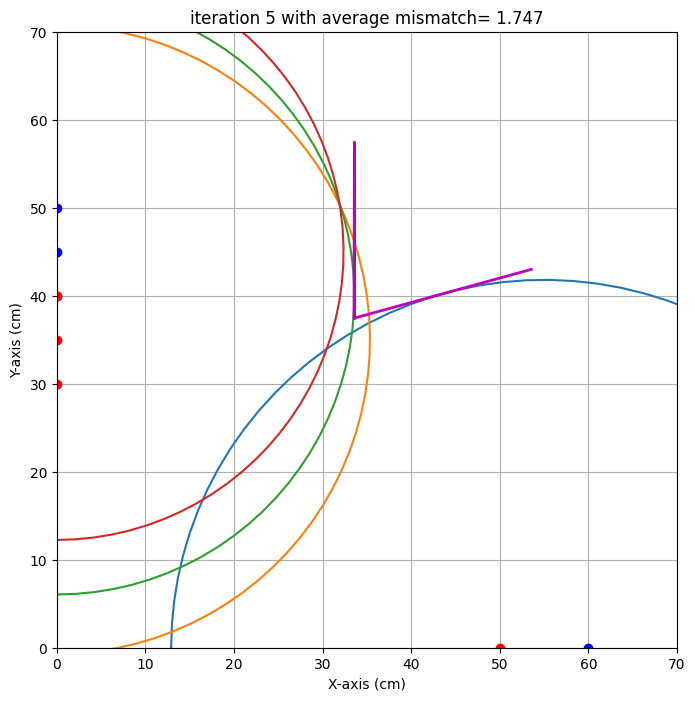

end iteration 5 with average mismatch= 1.747


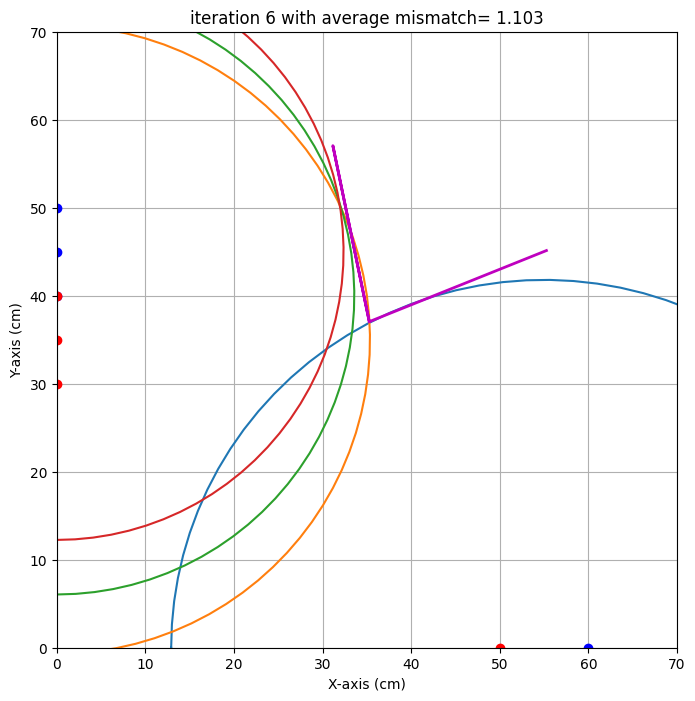

end iteration 6 with average mismatch= 1.103


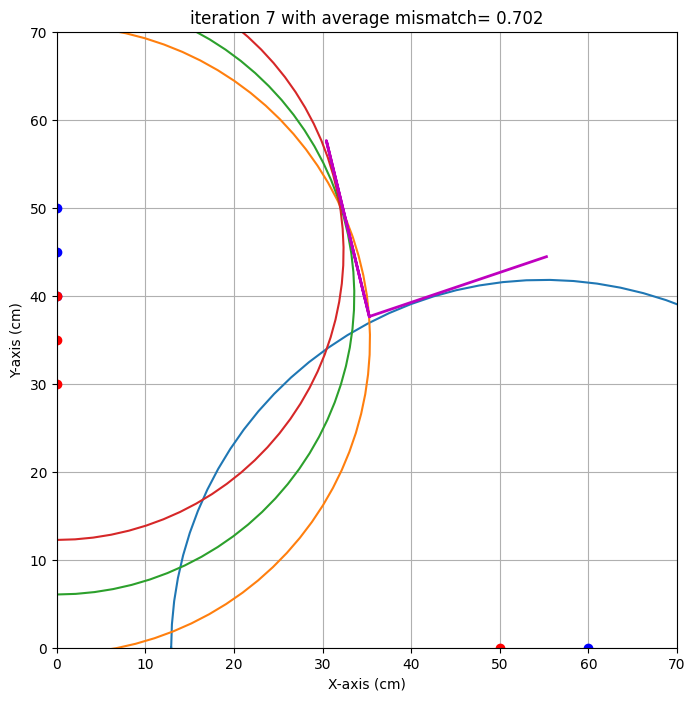

end iteration 7 with average mismatch= 0.702
end iteration 8 with average mismatch= 0.665


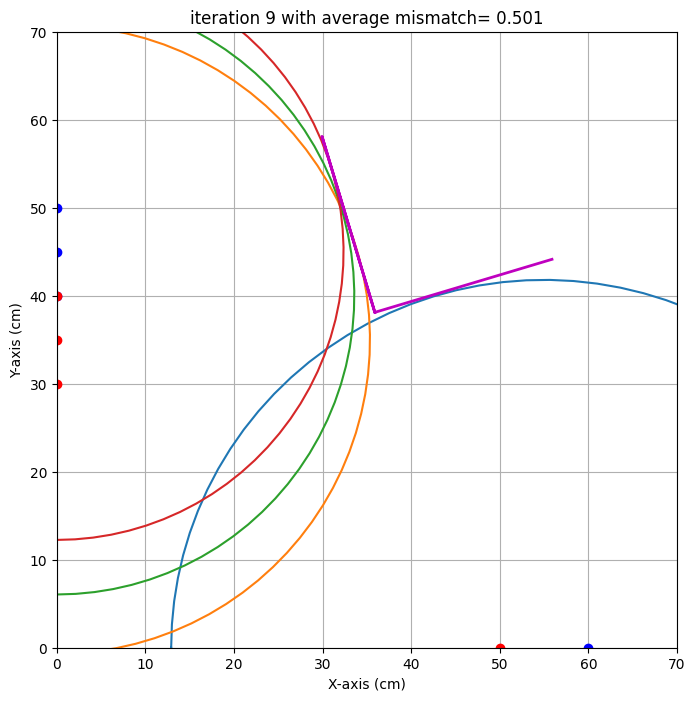

end iteration 9 with average mismatch= 0.501


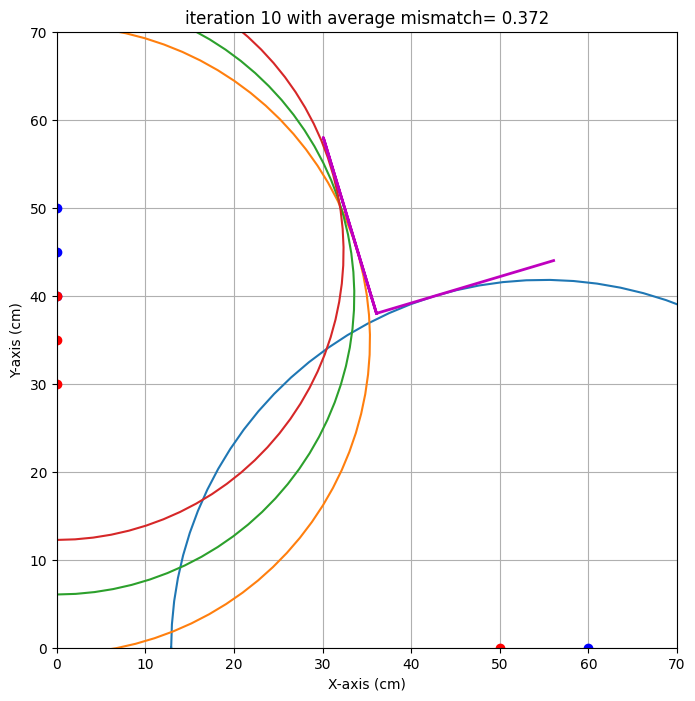

end iteration 10 with average mismatch= 0.372


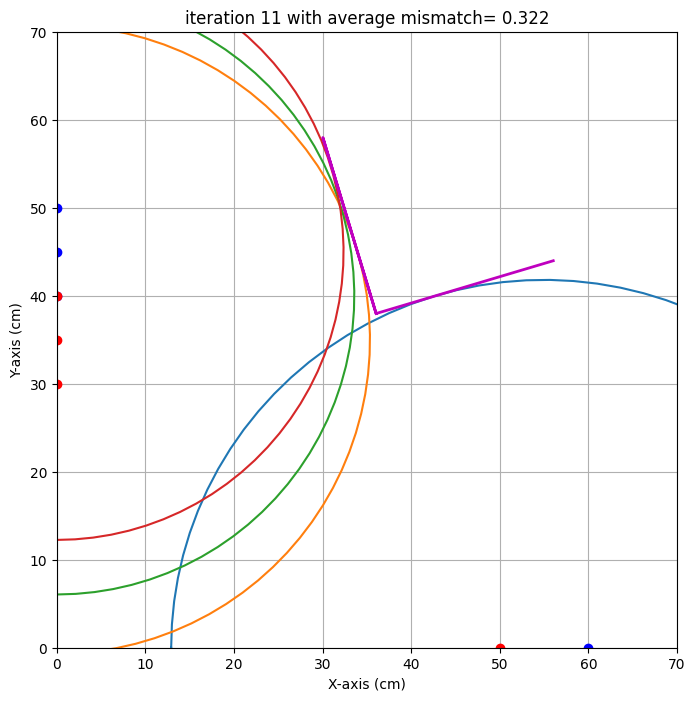

end iteration 11 with average mismatch= 0.322
end iteration 12 with average mismatch= 0.318
end iteration 13 with average mismatch= 0.317
end iteration 14 with average mismatch= 0.316
end iteration 15 with average mismatch= 0.316
end iteration 16 with average mismatch= 0.315
end iteration 17 with average mismatch= 0.315
end iteration 18 with average mismatch= 0.315
end iteration 19 with average mismatch= 0.315
end iteration 20 with average mismatch= 0.315
end iteration 21 with average mismatch= 0.315
end iteration 22 with average mismatch= 0.315
end iteration 23 with average mismatch= 0.315
end iteration 24 with average mismatch= 0.315
end iteration 25 with average mismatch= 0.315
end iteration 26 with average mismatch= 0.315
end iteration 27 with average mismatch= 0.315
end iteration 28 with average mismatch= 0.315
end iteration 29 with average mismatch= 0.315
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 

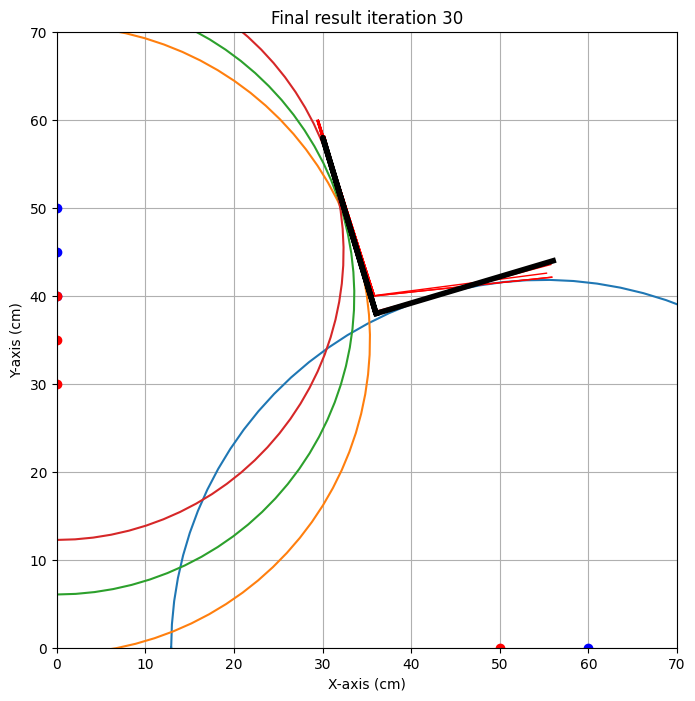

{'alpha': np.float64(16.691982146396757), 'alpha_eps': np.float64(10.623080405290478), 'beta': np.float64(-16.73372821452769), 'beta_eps': np.float64(1.225507974399065), 'x0': np.float64(36.02946464177463), 'x0_eps': np.float64(0.7522820250759139), 'y0': np.float64(37.97366315903203), 'y0_eps': np.float64(2.005964685481601)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Frank 
x0 target is : 35.0. Gevonden waarde: 29.3 cm met een standaardafwijking van 1.3 cm 
y0 target is : 32.0. Gevonden waarde: 30.9 cm met een standaardafwijking van 4.5 cm 
alpha target is : 30.0. Gevonden waarde: 1.3 graden met een standaardafwijking van 13.3 graad 
beta target is : 0.0. Gevonden waarde: 1.5 graden met een standaardafwijking van 6.6 graad 

Kimi 
x0 target is : 35.0. Gevonden waarde: 36.0 cm met een standaardafwijking van 0.8 cm 
y0 target is : 32.0. Gevonden waarde: 38.0 cm met een standaardafwijking van 2.0 cm 
alpha target is : 30.0. Gevonden waarde: 16.7 graden met een standaardafwijking van 10.6 graad 
beta target is : 0.0. Gevonden waarde: -16.7 graden met een standaardafwijking van 1.2 graad 



## Opdracht 8: Iteratie1+.14:20.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](Iteratie1.jpeg)


## Iteratie 15:02.

Nu naar iteratie 2

Figuur: ![Alt](iteratie2.jpeg)

In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  45   0  20   0  61.0
1  70   0  30   0  70.2
2   0  45   0  20  56.9
3   0  45   0  70  65.9
4  20   0  70   0  77.1
5   0  70   0  20  73.3


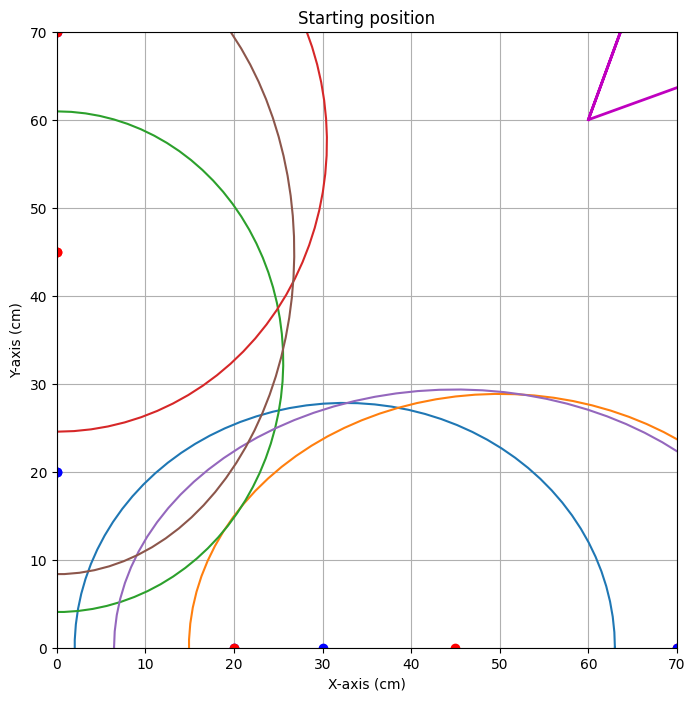


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=69.422


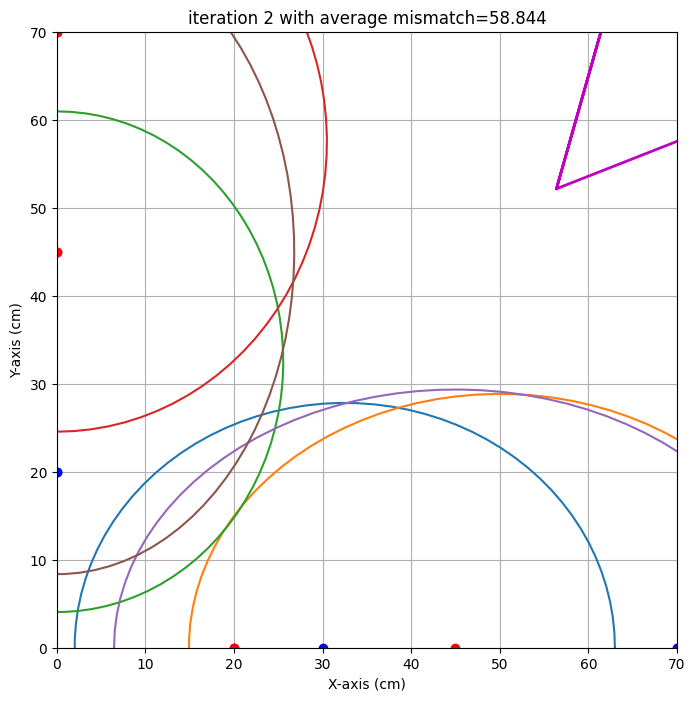

end iteration 2 with average mismatch=58.844


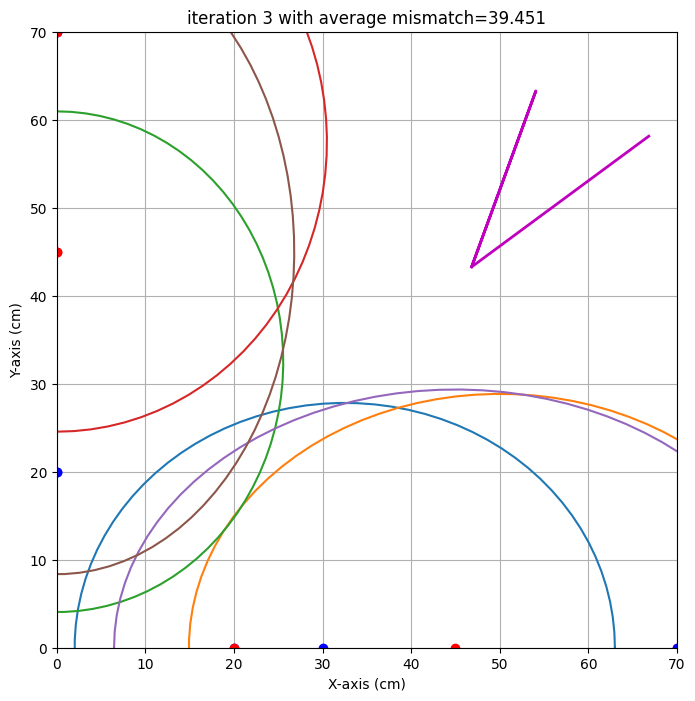

end iteration 3 with average mismatch=39.451


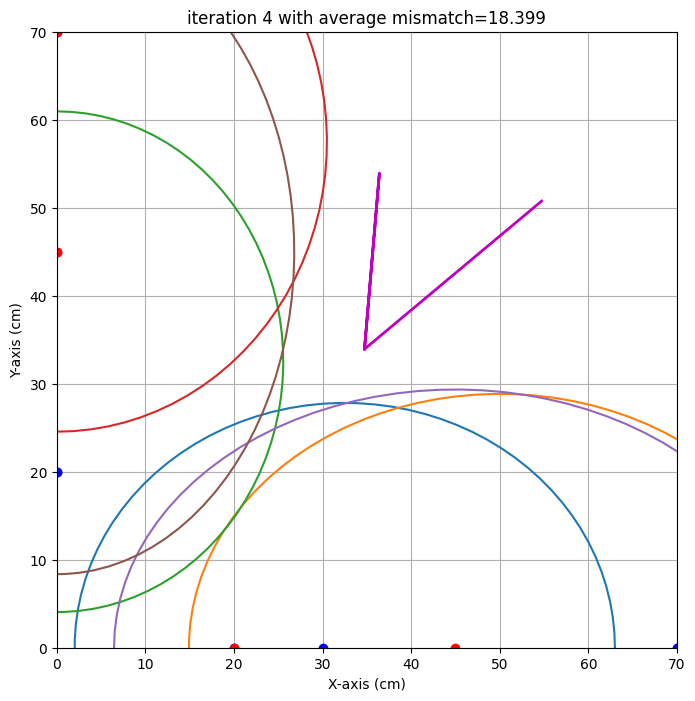

end iteration 4 with average mismatch=18.399


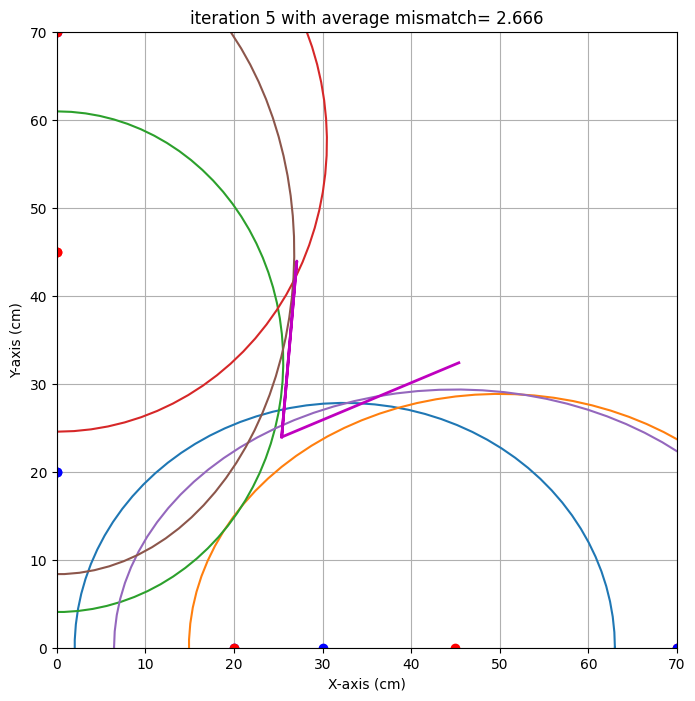

end iteration 5 with average mismatch= 2.666


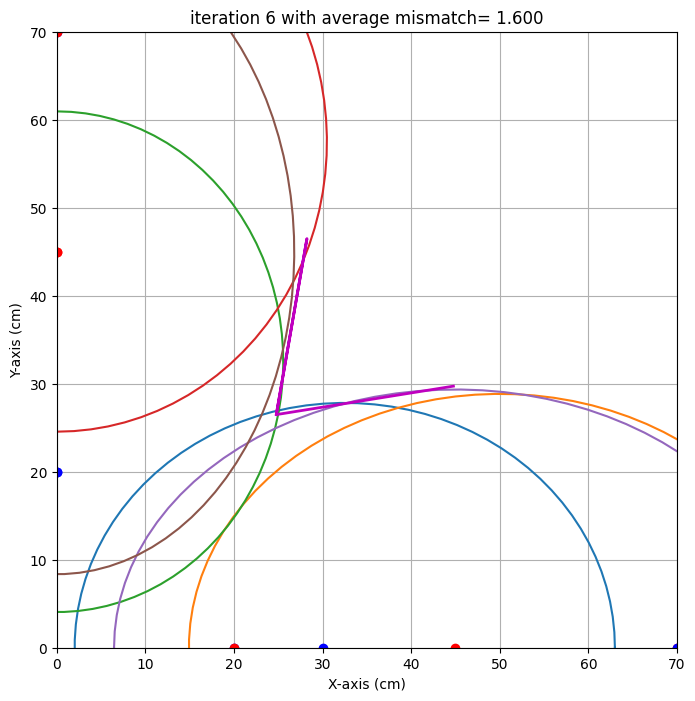

end iteration 6 with average mismatch= 1.600


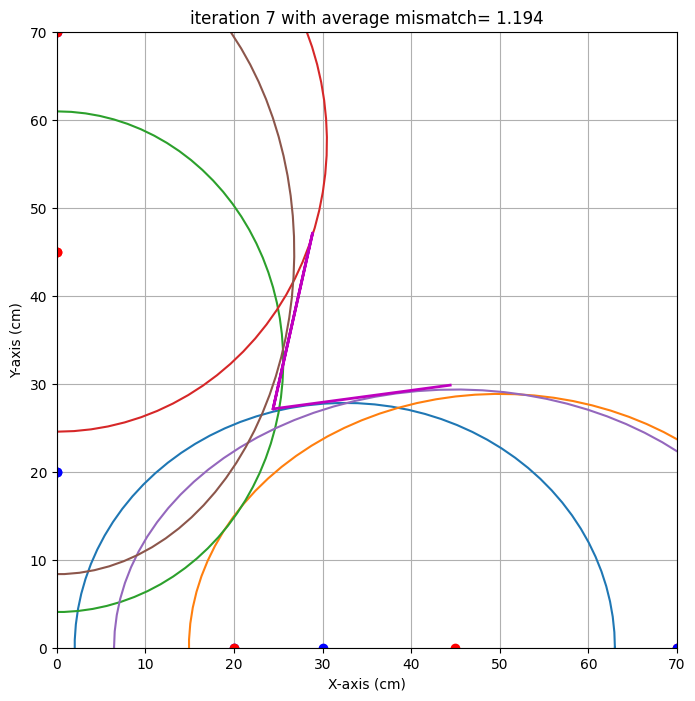

end iteration 7 with average mismatch= 1.194
end iteration 8 with average mismatch= 1.080
end iteration 9 with average mismatch= 1.080
end iteration 10 with average mismatch= 1.016
end iteration 11 with average mismatch= 1.015
end iteration 12 with average mismatch= 1.015
end iteration 13 with average mismatch= 1.015
end iteration 14 with average mismatch= 1.015
end iteration 15 with average mismatch= 1.015
end iteration 16 with average mismatch= 1.015
end iteration 17 with average mismatch= 1.015
end iteration 18 with average mismatch= 1.015
end iteration 19 with average mismatch= 1.015
end iteration 20 with average mismatch= 1.015
end iteration 21 with average mismatch= 1.015
end iteration 22 with average mismatch= 1.015
end iteration 23 with average mismatch= 1.015
end iteration 24 with average mismatch= 1.015
end iteration 25 with average mismatch= 1.015
end iteration 26 with average mismatch= 1.015
end iteration 27 with average mismatch= 1.015
end iteration 28 with average mismatc

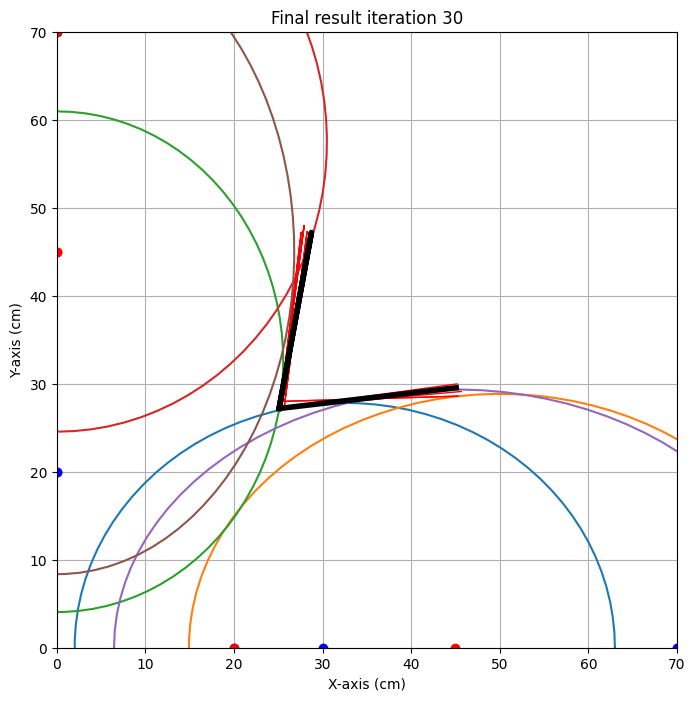

{'alpha': np.float64(6.711058277443372), 'alpha_eps': np.float64(4.992576730664149), 'beta': np.float64(10.353127169094298), 'beta_eps': np.float64(3.5090917454163364), 'x0': np.float64(25.08474940216098), 'x0_eps': np.float64(0.5740889321033791), 'y0': np.float64(27.18546022776921), 'y0_eps': np.float64(0.8019539953058299)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  60   0  85.2
1  45   0  70   0  87.5
2   0  40   0  60  82.3
3   0  45   0  70  84.0


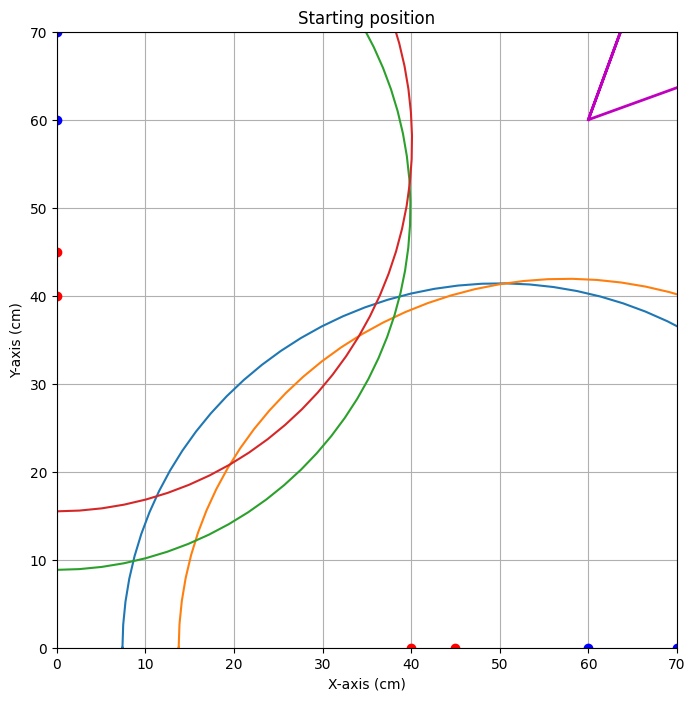


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=43.962


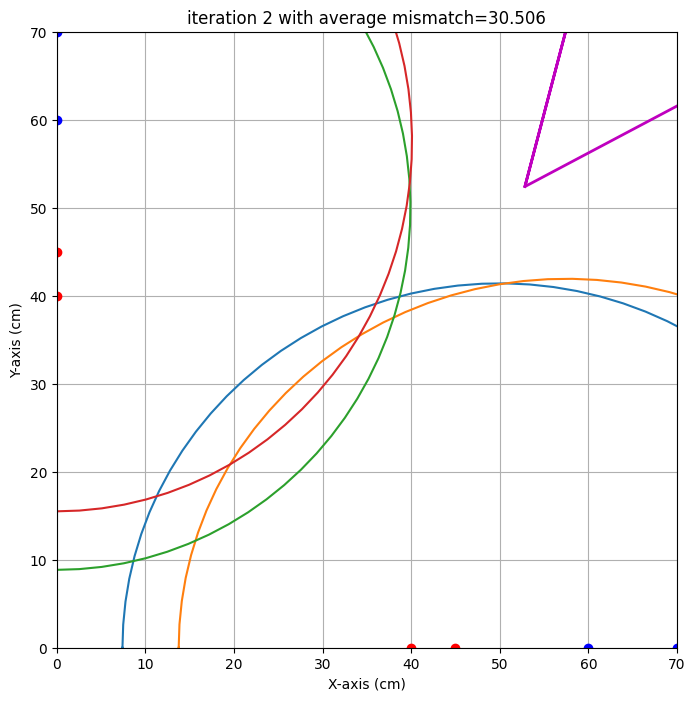

end iteration 2 with average mismatch=30.506


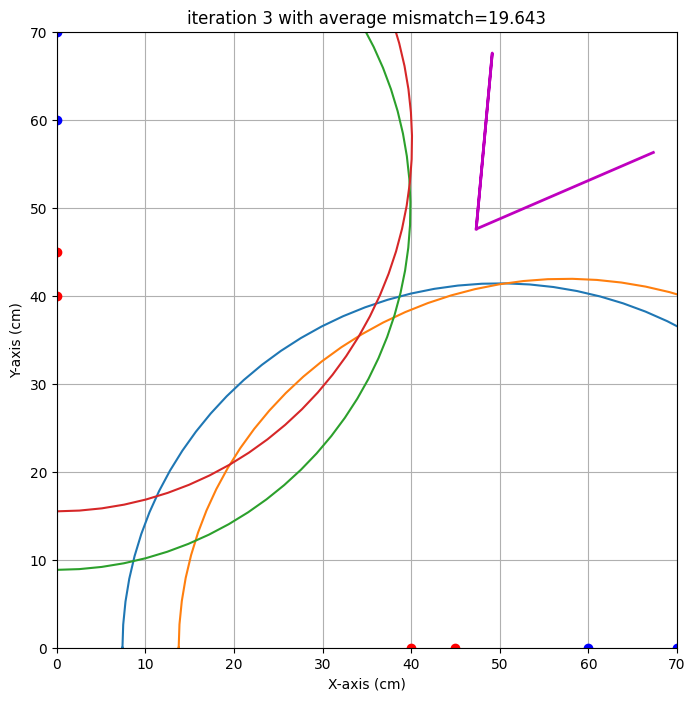

end iteration 3 with average mismatch=19.643


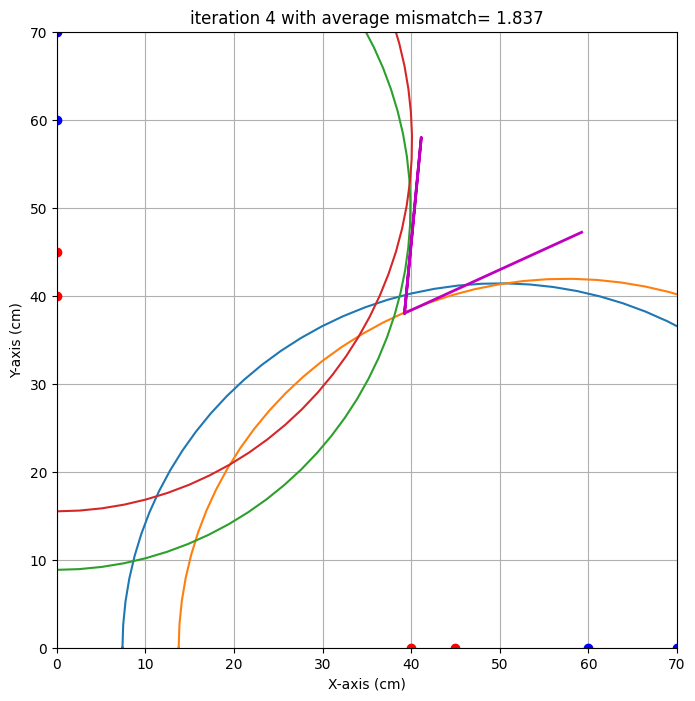

end iteration 4 with average mismatch= 1.837


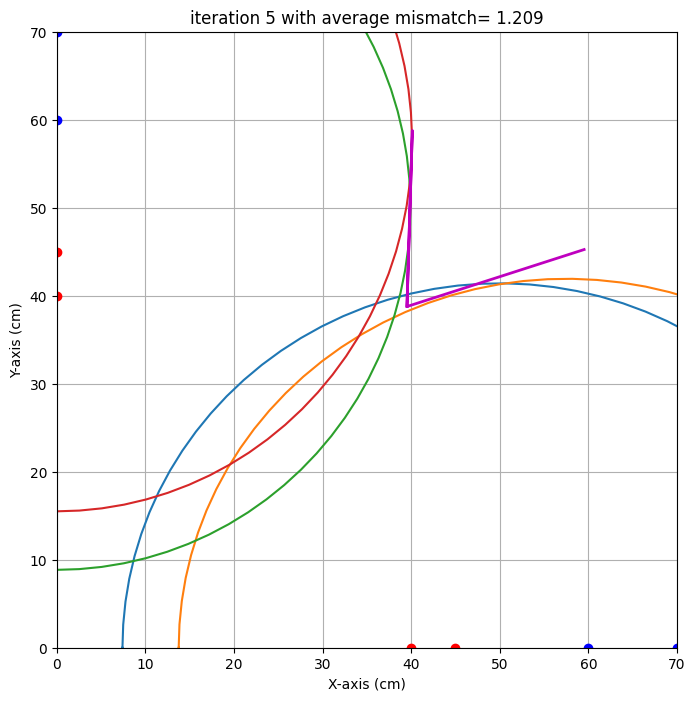

end iteration 5 with average mismatch= 1.209


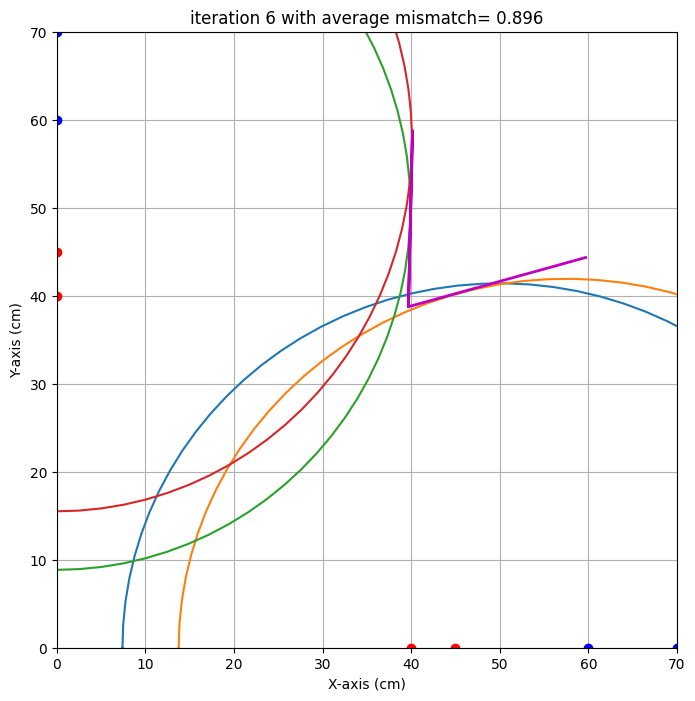

end iteration 6 with average mismatch= 0.896
end iteration 7 with average mismatch= 0.890
end iteration 8 with average mismatch= 0.886
end iteration 9 with average mismatch= 0.841


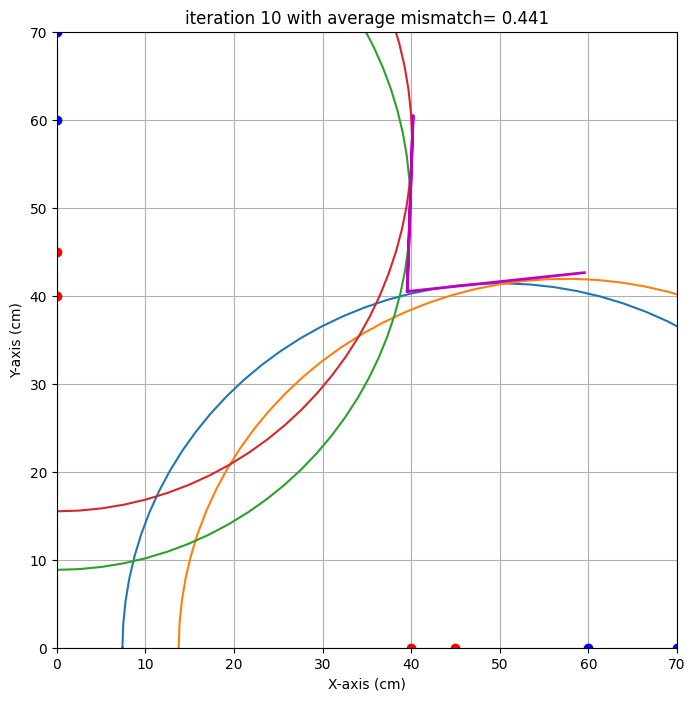

end iteration 10 with average mismatch= 0.441


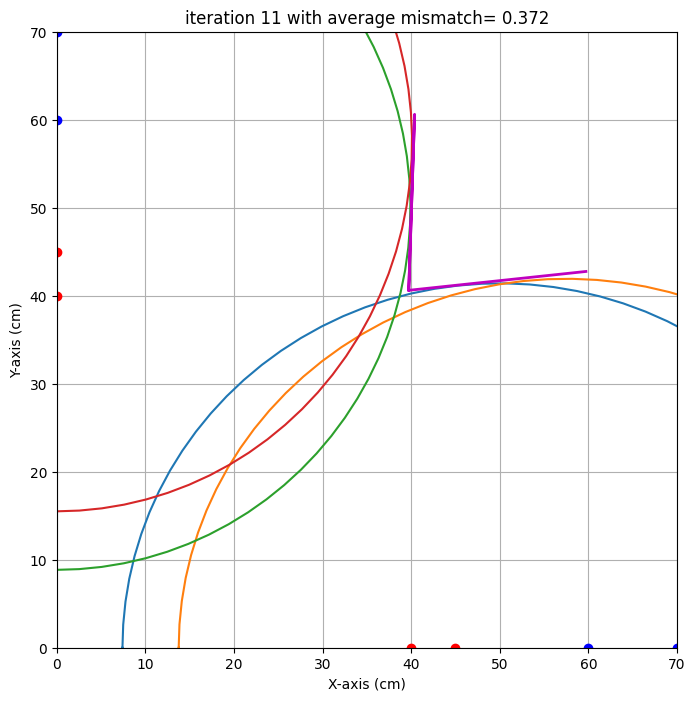

end iteration 11 with average mismatch= 0.372


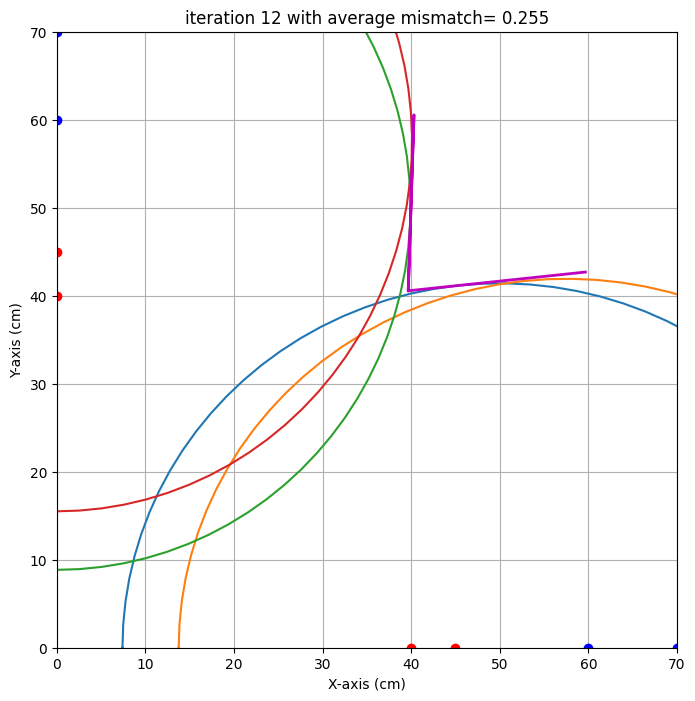

end iteration 12 with average mismatch= 0.255
end iteration 13 with average mismatch= 0.253
end iteration 14 with average mismatch= 0.253
end iteration 15 with average mismatch= 0.253
end iteration 16 with average mismatch= 0.253
end iteration 17 with average mismatch= 0.253
end iteration 18 with average mismatch= 0.253
end iteration 19 with average mismatch= 0.253
end iteration 20 with average mismatch= 0.253
end iteration 21 with average mismatch= 0.253
end iteration 22 with average mismatch= 0.253
end iteration 23 with average mismatch= 0.253
end iteration 24 with average mismatch= 0.232
end iteration 25 with average mismatch= 0.228
end iteration 26 with average mismatch= 0.226
end iteration 27 with average mismatch= 0.226
end iteration 28 with average mismatch= 0.223
end iteration 29 with average mismatch= 0.223
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.223
#################

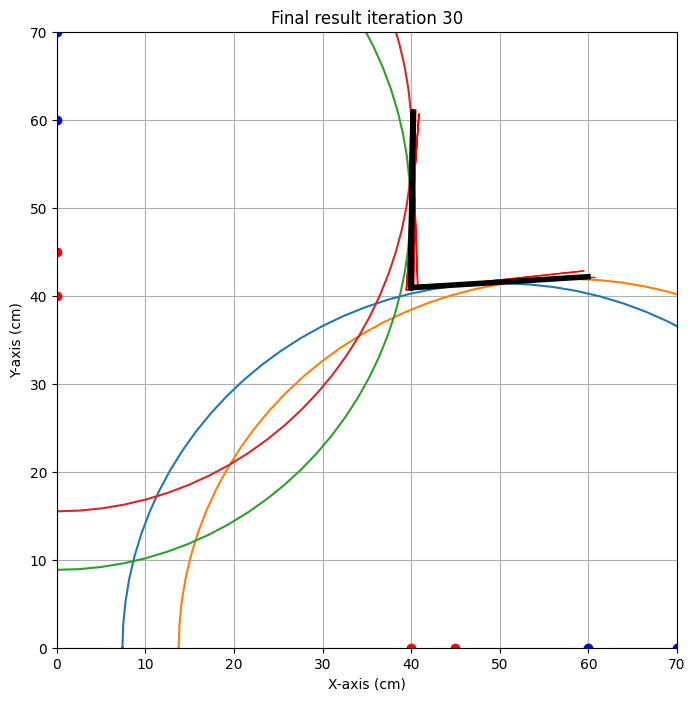

{'alpha': np.float64(3.5479004091686517), 'alpha_eps': np.float64(2.6008027394159074), 'beta': np.float64(0.7132873105855481), 'beta_eps': np.float64(3.3595173876776365), 'x0': np.float64(39.949515154928726), 'x0_eps': np.float64(0.7831881888182863), 'y0': np.float64(40.91394515457547), 'y0_eps': np.float64(0.2583935025516766)}
locatie 1 
x0 target is : 22.0. Gevonden waarde: 25.1 cm met een standaardafwijking van 0.6 cm 
y0 target is : 26.0. Gevonden waarde: 27.2 cm met een standaardafwijking van 0.8 cm 
alpha target is : 10.0. Gevonden waarde: 6.7 graden met een standaardafwijking van 5.0 graad 
beta target is : 20.0. Gevonden waarde: 10.4 graden met een standaardafwijking van 3.5 graad 

locatie 2 
x0 target is : 39.0. Gevonden waarde: 39.9 cm met een standaardafwijking van 0.8 cm 
y0 target is : 39.0. Gevonden waarde: 40.9 cm met een standaardafwijking van 0.3 cm 
alpha target is : 5.0. Gevonden waarde: 3.5 graden met een standaardafwijking van 2.6 graad 
beta target is : 5.0. Gevo

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:
# Dit is iteratie 1

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':22,
                    'y0':26,
                    'alpha' : 10,
                    'beta' : 20,},
            'locatie 2':{'x0':39,
                     'y0':39,
                     'alpha' : 5,
                     'beta' : 5}
             }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [45, 0, 20, 0, 61.0],
    [70, 0, 30, 0, 70.2],
    [0, 45, 0, 20, 56.9],
    [0, 45, 0, 70, 65.9],
    [20, 0, 70, 0, 77.1],
    [0, 70, 0, 20, 73.3],
    ]),
        'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[45, 0, 20, 0, -]
    [40, 0, 60, 0, 85.2],
    [45, 0, 70, 0, 87.5],
    #[0, 45, 0, 20, -]
    [0, 40, 0, 60, 82.3],
    [0, 45, 0, 70, 84.0]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  71.6
1  45   0  70   0  78.3
2   0  45   0  20  89.0
3   0  45   0  70  85.4
4  20   0  70   0  88.4
5   0  70   0  20  93.6
6   0  25   0  45  86.4
7   0  50   0  65  83.5
8  50   0  65   0  76.0


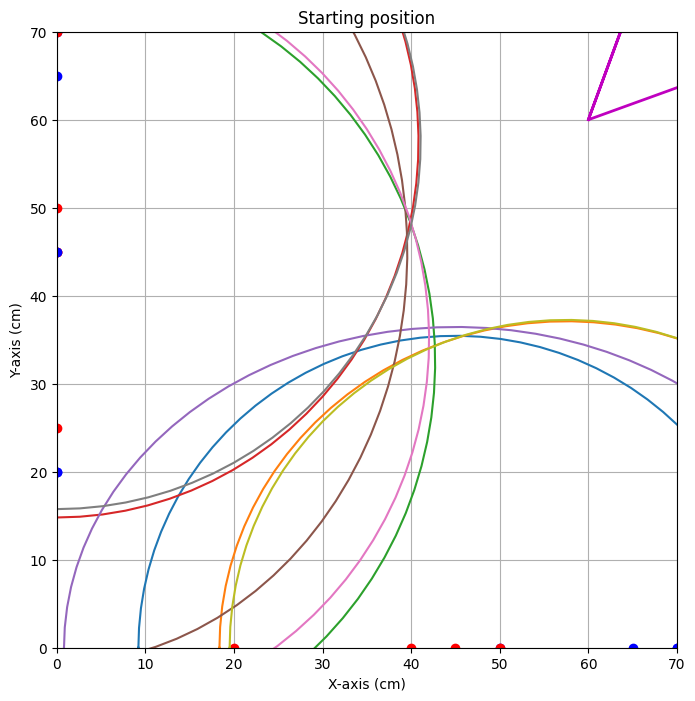


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=49.270


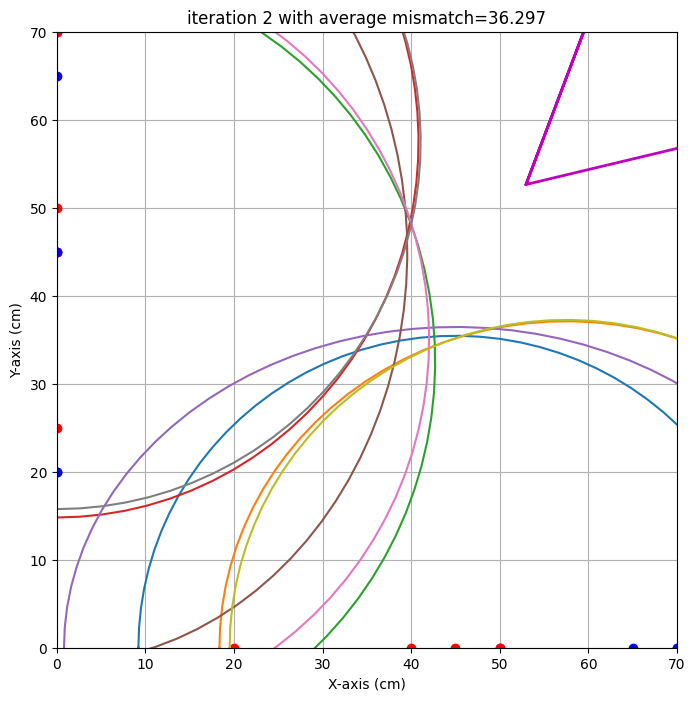

end iteration 2 with average mismatch=36.297


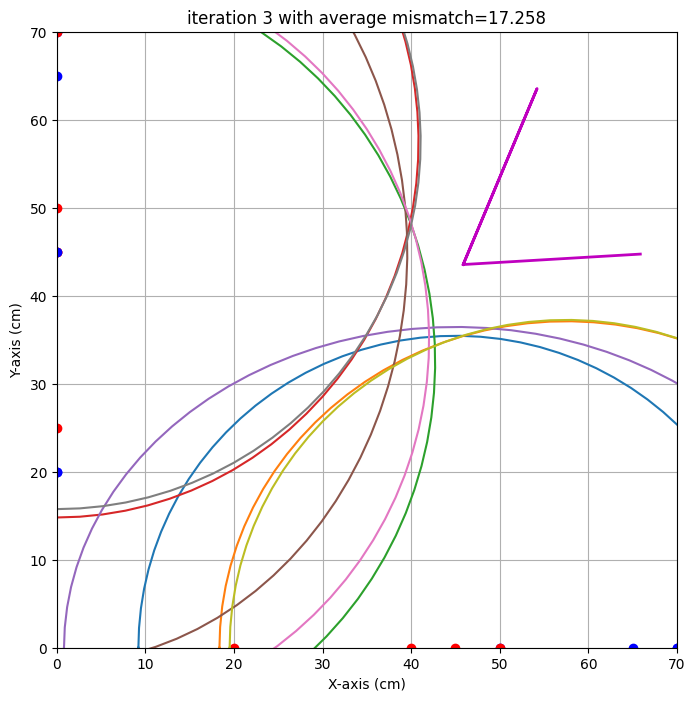

end iteration 3 with average mismatch=17.258


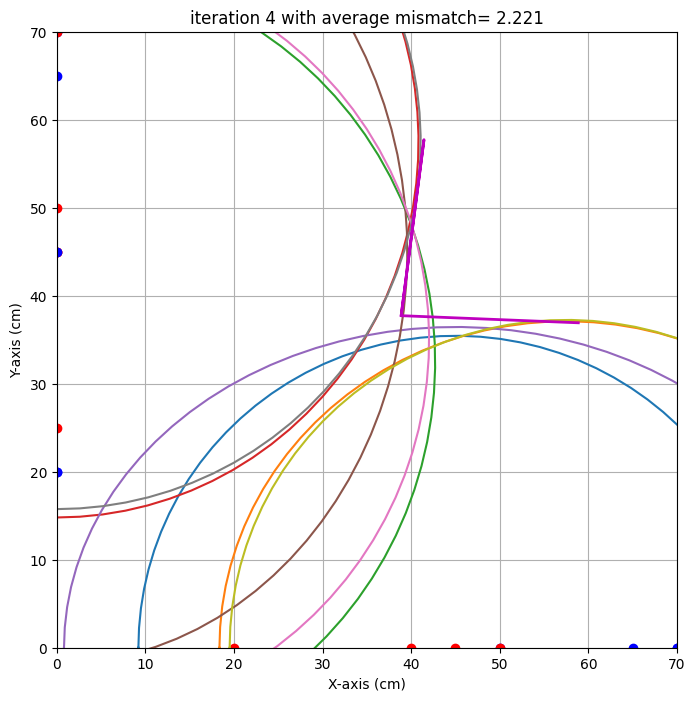

end iteration 4 with average mismatch= 2.221


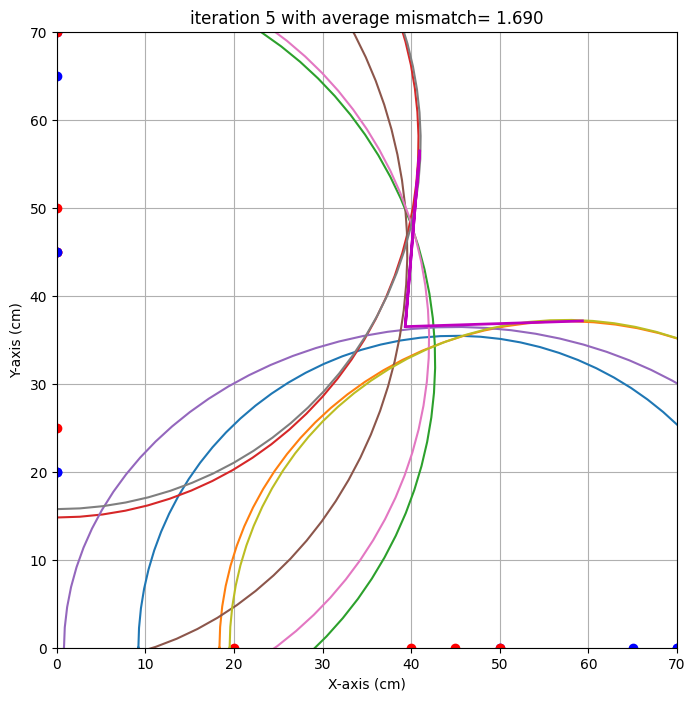

end iteration 5 with average mismatch= 1.690
end iteration 6 with average mismatch= 1.689
end iteration 7 with average mismatch= 1.689
end iteration 8 with average mismatch= 1.584
end iteration 9 with average mismatch= 1.483
end iteration 10 with average mismatch= 1.462
end iteration 11 with average mismatch= 1.460
end iteration 12 with average mismatch= 1.459
end iteration 13 with average mismatch= 1.459
end iteration 14 with average mismatch= 1.459
end iteration 15 with average mismatch= 1.459
end iteration 16 with average mismatch= 1.459
end iteration 17 with average mismatch= 1.459
end iteration 18 with average mismatch= 1.459
end iteration 19 with average mismatch= 1.459
end iteration 20 with average mismatch= 1.459
end iteration 21 with average mismatch= 1.459
end iteration 22 with average mismatch= 1.459
end iteration 23 with average mismatch= 1.459
end iteration 24 with average mismatch= 1.459
end iteration 25 with average mismatch= 1.459
end iteration 26 with average mismatch=

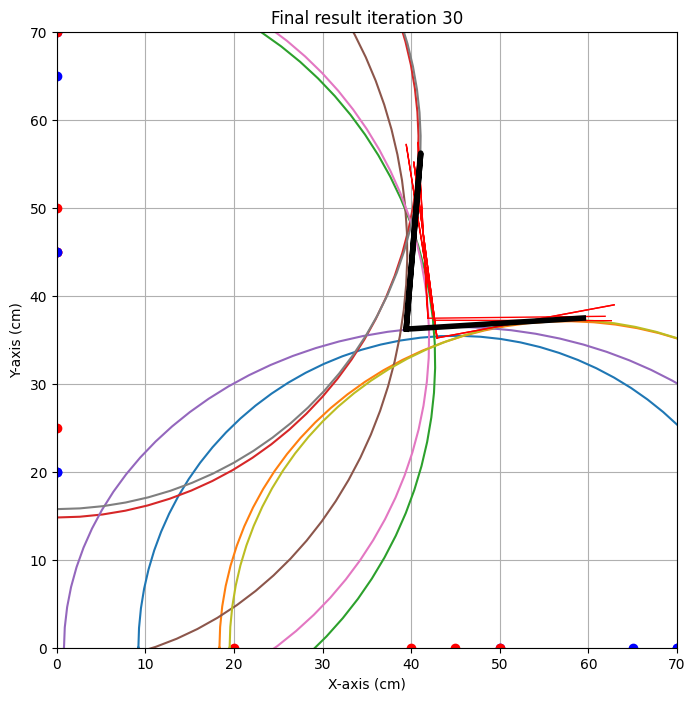

{'alpha': np.float64(3.596040399249491), 'alpha_eps': np.float64(7.049759790782273), 'beta': np.float64(4.705968965828957), 'beta_eps': np.float64(13.685543339120887), 'x0': np.float64(39.43323993114646), 'x0_eps': np.float64(3.4791375593012717), 'y0': np.float64(36.20337271539458), 'y0_eps': np.float64(1.2387123132192244)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  60   0  85.1
1  45   0  70   0  86.8
2   0  40   0  60  88.5
3   0  45   0  70  92.5
4   0  50   0  65  89.0
5  50   0  65   0  84.5


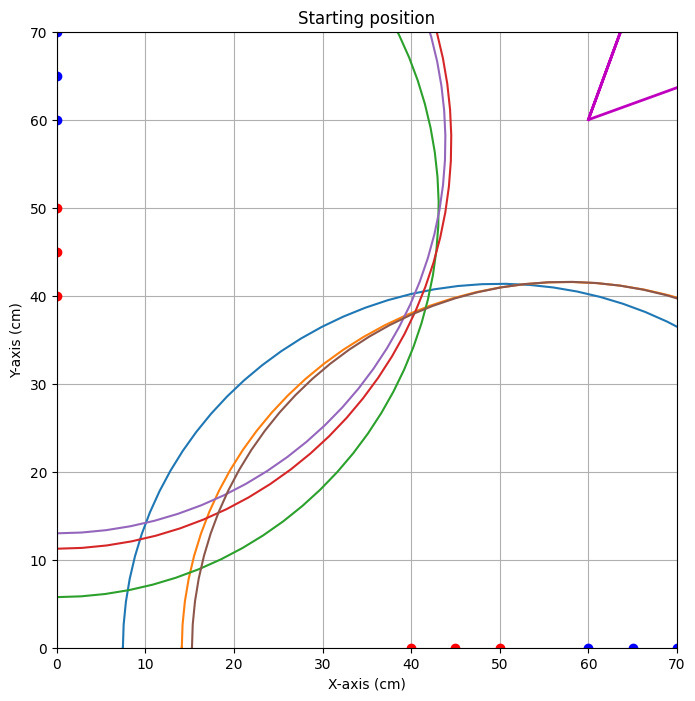


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=40.258


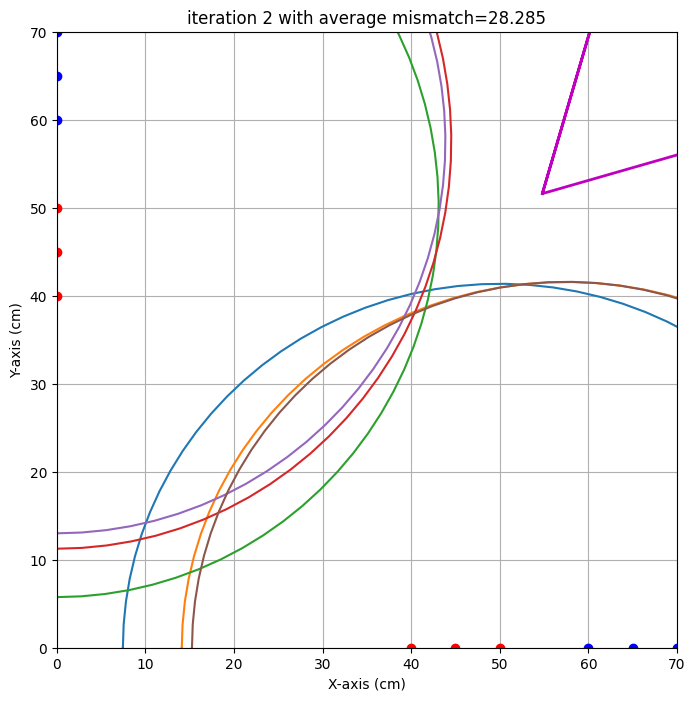

end iteration 2 with average mismatch=28.285


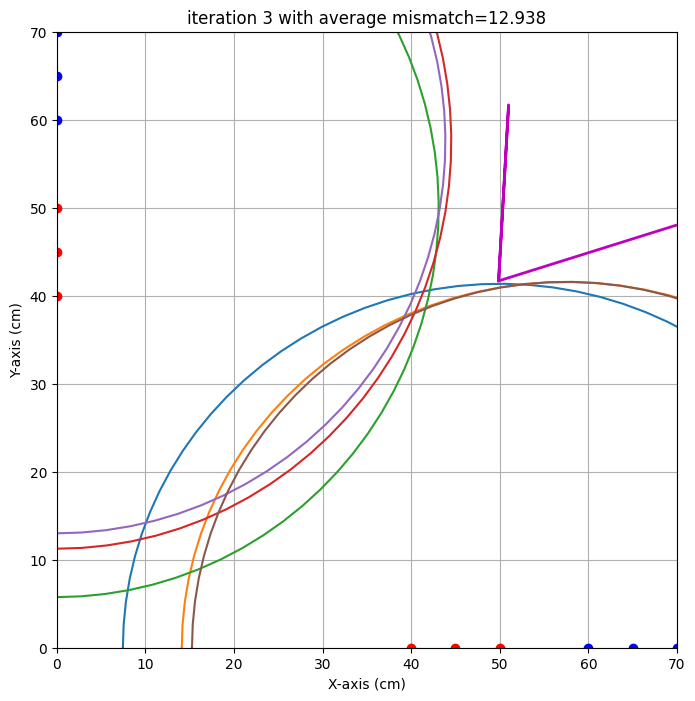

end iteration 3 with average mismatch=12.938


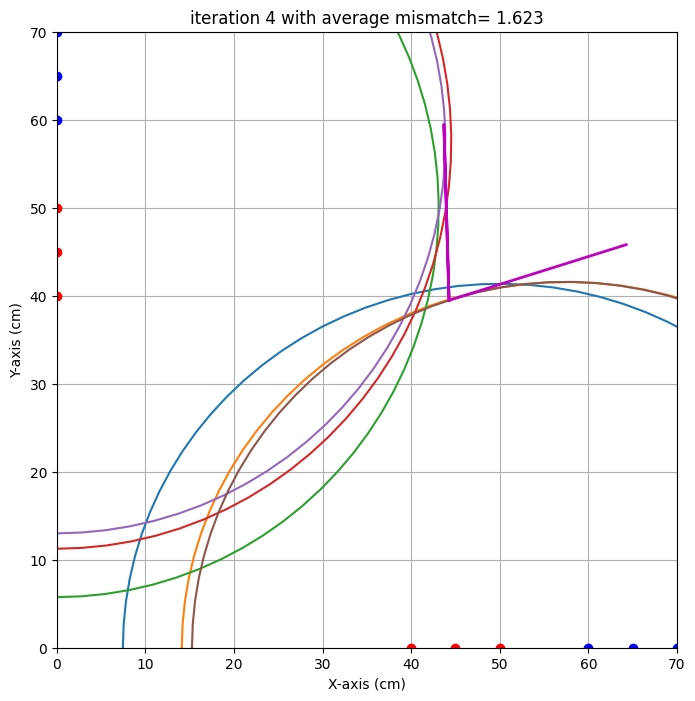

end iteration 4 with average mismatch= 1.623


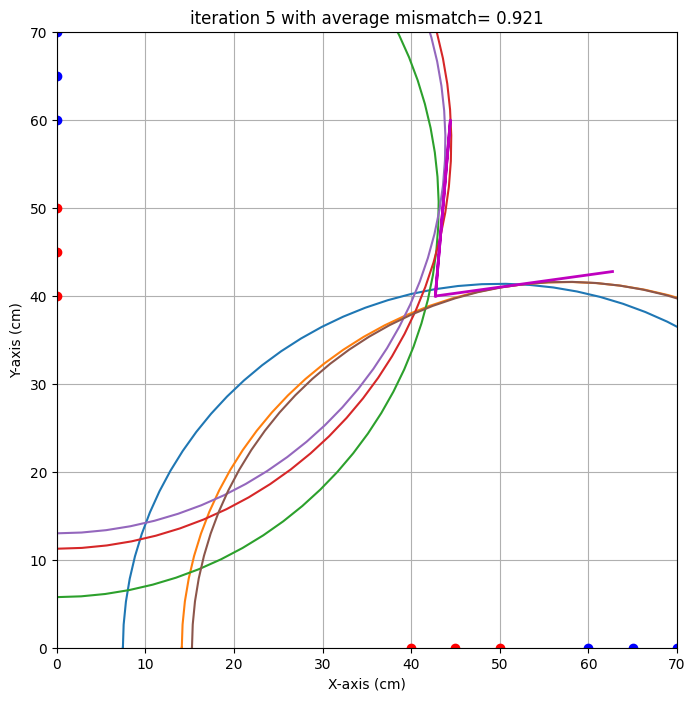

end iteration 5 with average mismatch= 0.921


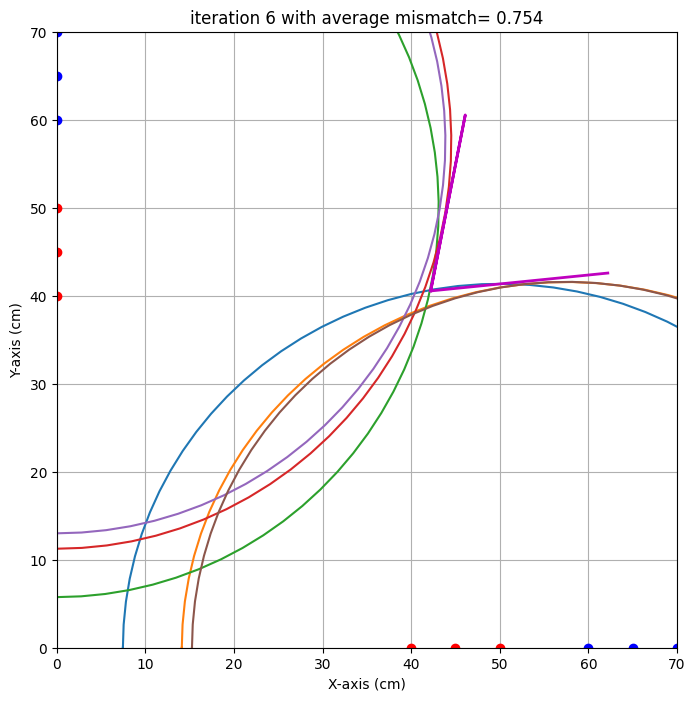

end iteration 6 with average mismatch= 0.754


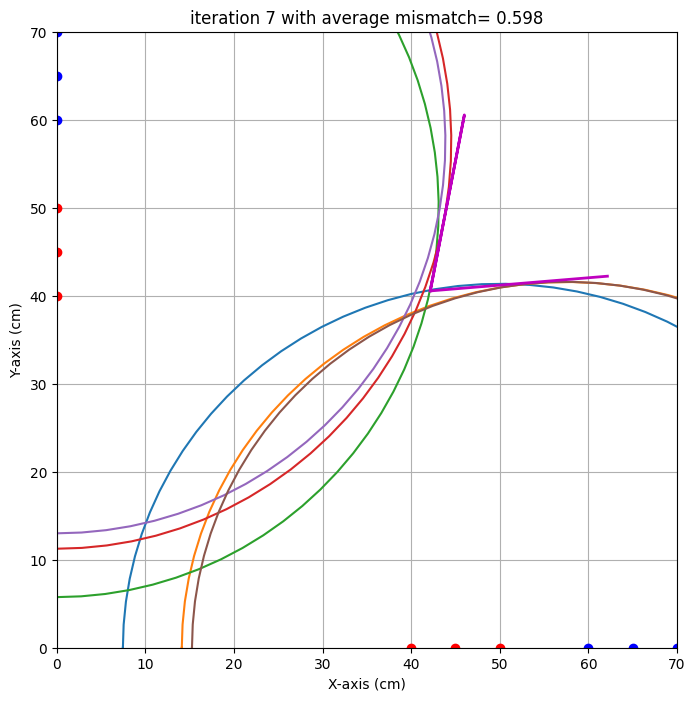

end iteration 7 with average mismatch= 0.598
end iteration 8 with average mismatch= 0.586
end iteration 9 with average mismatch= 0.567
end iteration 10 with average mismatch= 0.561
end iteration 11 with average mismatch= 0.560
end iteration 12 with average mismatch= 0.560
end iteration 13 with average mismatch= 0.535
end iteration 14 with average mismatch= 0.527
end iteration 15 with average mismatch= 0.508
end iteration 16 with average mismatch= 0.478
end iteration 17 with average mismatch= 0.470
end iteration 18 with average mismatch= 0.467


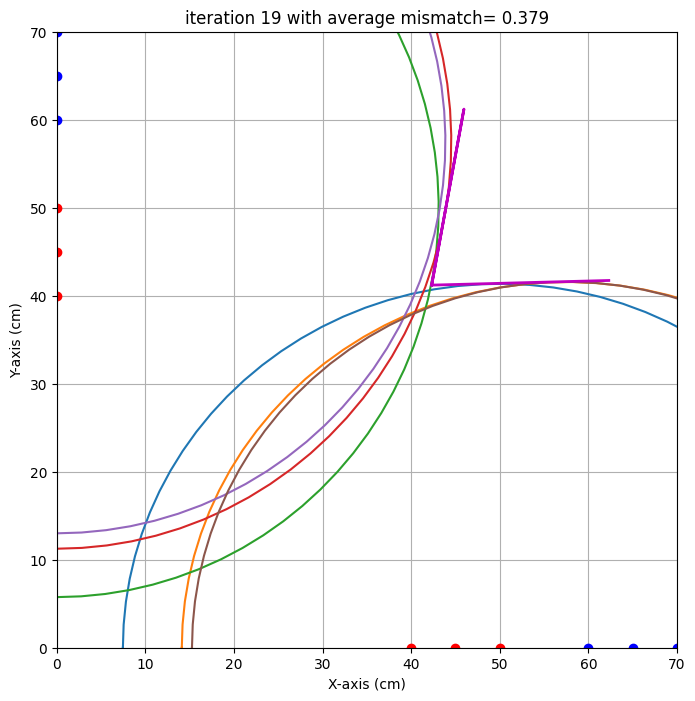

end iteration 19 with average mismatch= 0.379
end iteration 20 with average mismatch= 0.368
end iteration 21 with average mismatch= 0.366
end iteration 22 with average mismatch= 0.366
end iteration 23 with average mismatch= 0.366
end iteration 24 with average mismatch= 0.366
end iteration 25 with average mismatch= 0.366
end iteration 26 with average mismatch= 0.366
end iteration 27 with average mismatch= 0.366
end iteration 28 with average mismatch= 0.366
end iteration 29 with average mismatch= 0.366
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.366
###############################################################################
end of iteration  30
Best alpha=   1.50 with uncertainty=   1.84
Best beta =  10.33 with uncertainty=   5.39
Best x0   =  42.31 with uncertainty=   0.34
Best y0   =  41.19 with uncertainty=   0.34
##############################################################

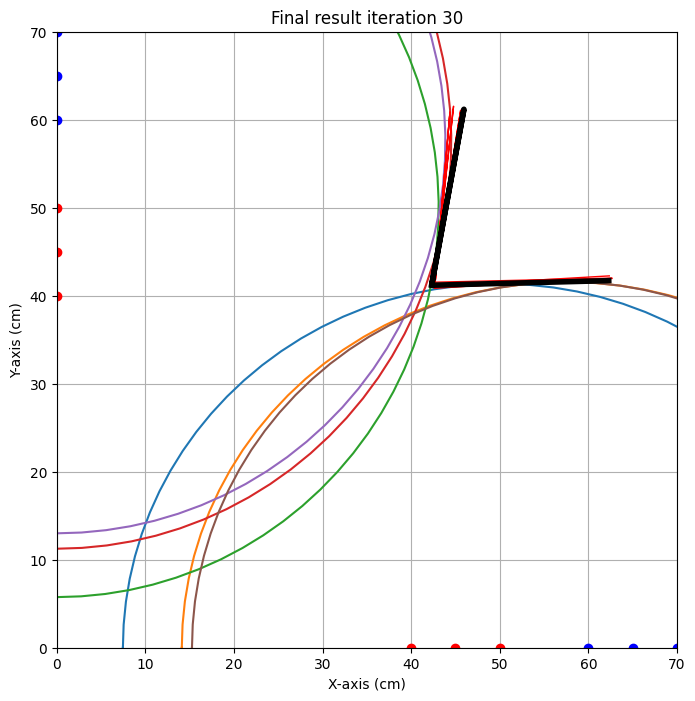

{'alpha': np.float64(1.5012517957240799), 'alpha_eps': np.float64(1.8413423900186165), 'beta': np.float64(10.334922806765075), 'beta_eps': np.float64(5.385337961196635), 'x0': np.float64(42.30635188458401), 'x0_eps': np.float64(0.3419062942241382), 'y0': np.float64(41.19046048877948), 'y0_eps': np.float64(0.3448637236281371)}
locatie 1 
x0 target is : 38.0. Gevonden waarde: 39.4 cm met een standaardafwijking van 3.5 cm 
y0 target is : 32.0. Gevonden waarde: 36.2 cm met een standaardafwijking van 1.2 cm 
alpha target is : 10.0. Gevonden waarde: 3.6 graden met een standaardafwijking van 7.0 graad 
beta target is : 10.0. Gevonden waarde: 4.7 graden met een standaardafwijking van 13.7 graad 

locatie 2 
x0 target is : 42.0. Gevonden waarde: 42.3 cm met een standaardafwijking van 0.3 cm 
y0 target is : 38.0. Gevonden waarde: 41.2 cm met een standaardafwijking van 0.3 cm 
alpha target is : 15.0. Gevonden waarde: 1.5 graden met een standaardafwijking van 1.8 graad 
beta target is : 10.0. Gevo

In [12]:
# Voeg hier je meetgegevens van deze iteratie in:
# Dit is iteratie nummer 2

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':38,
                    'y0':32,
                    'alpha' : 10,
                    'beta' : 10,},
           'locatie 2':{'x0':42,
                    'y0':38,
                    'alpha' : 15,
                    'beta' : 10}
             }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[45, 0, 20, 0, x],
    [40, 0, 50, 0, 71.6],
    [45, 0, 70, 0, 78.3],
    [0, 45, 0, 20, 89.0],
    [0, 45, 0, 70, 85.4],
    [20, 0, 70, 0, 88.4],
    [0, 70, 0, 20, 93.6],
    [0, 25, 0, 45, 86.4],
    #[25, 0, 45, 0, -],
    [0, 50, 0, 65, 83.5],
    [50, 0, 65, 0, 76.0]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[45, 0, 20, 0, -],
    [40, 0, 60, 0, 85.1],
    [45, 0, 70, 0, 86.8],
    #[0, 45, 0, 20, -],
    [0, 40, 0, 60, 88.5],
    [0, 45, 0, 70, 92.5],
    #[20, 0, 70, 0, -],
    #[0, 70, 0, 20, -],
    #[0, 25, 0 45, -],
    [0, 50, 0, 65, 89.0],
    #[25, 0, 45, 0, -],
    [50, 0, 65, 0, 84.5]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  45   0  20   0  57.7
1  70   0  30   0  67.1
2   0  45   0  20  53.3
3  20   0  70   0  72.8
4   0  25   0  45  50.2
5  25   0  45   0  55.8


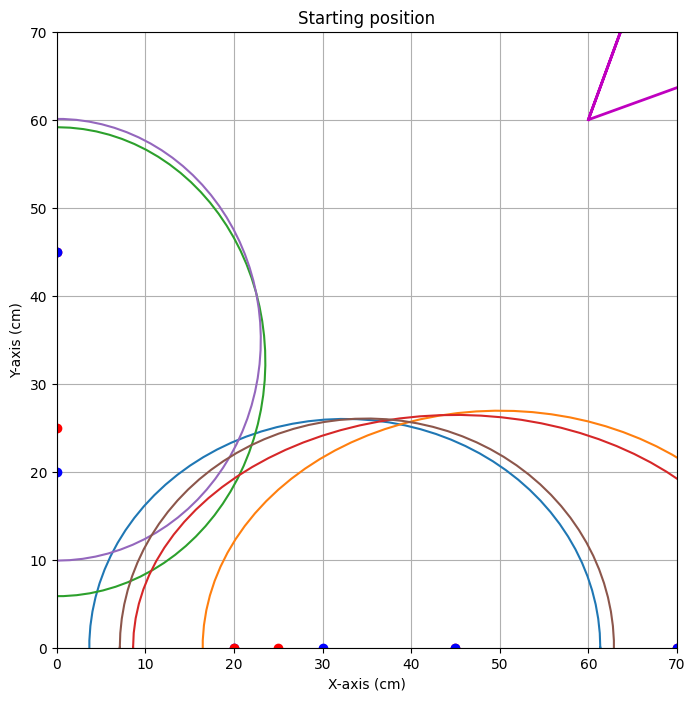


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=79.881


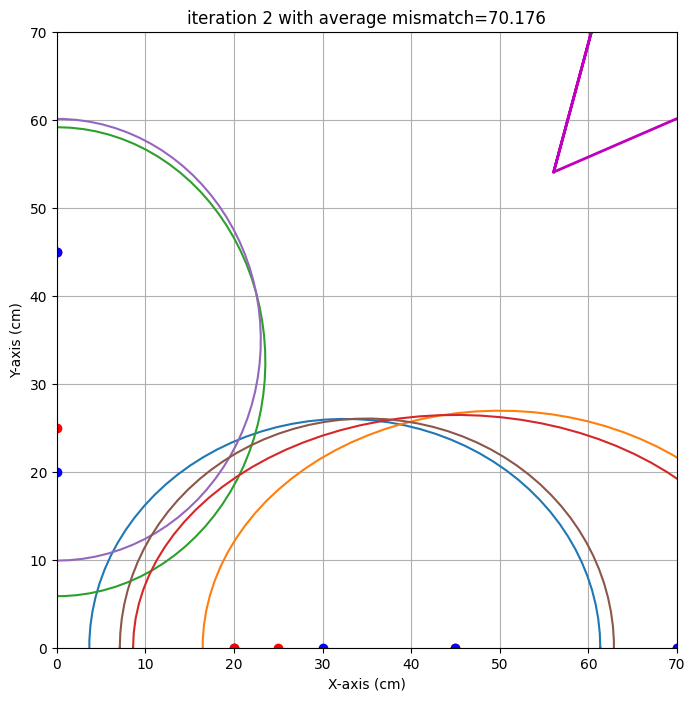

end iteration 2 with average mismatch=70.176


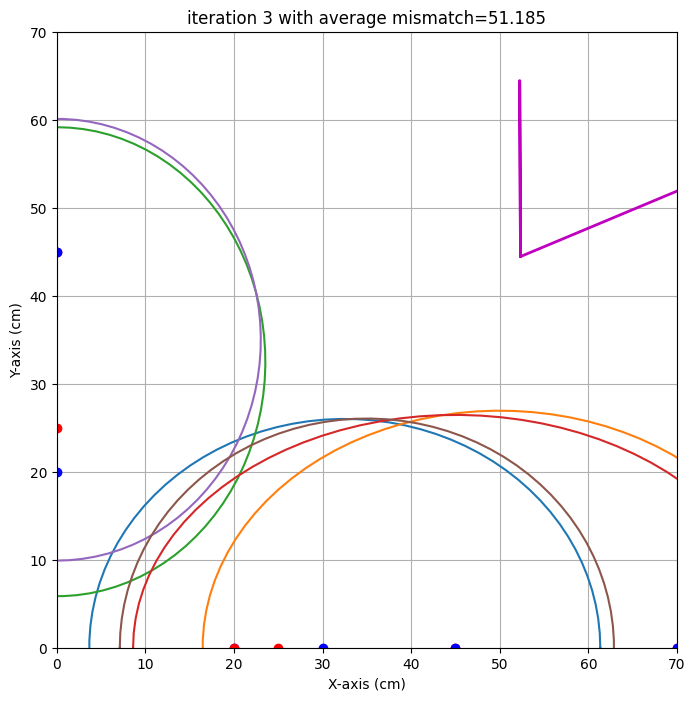

end iteration 3 with average mismatch=51.185


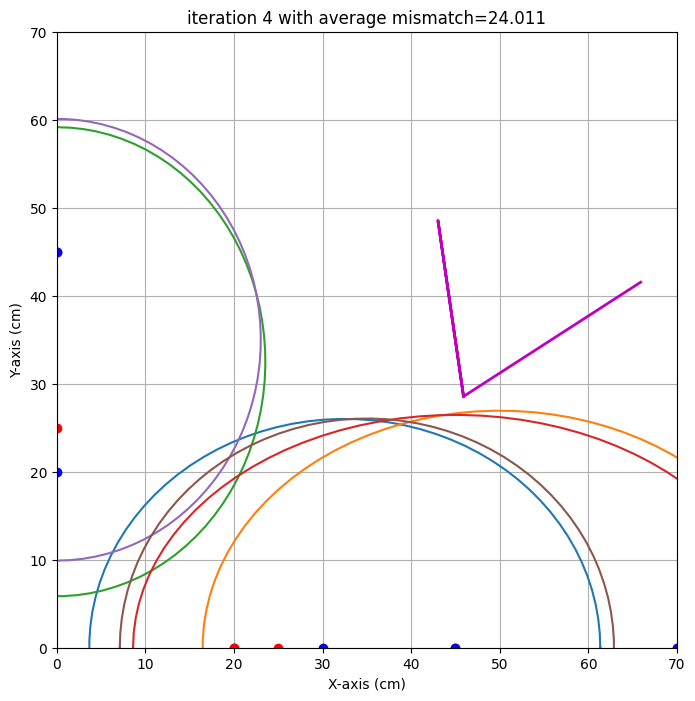

end iteration 4 with average mismatch=24.011


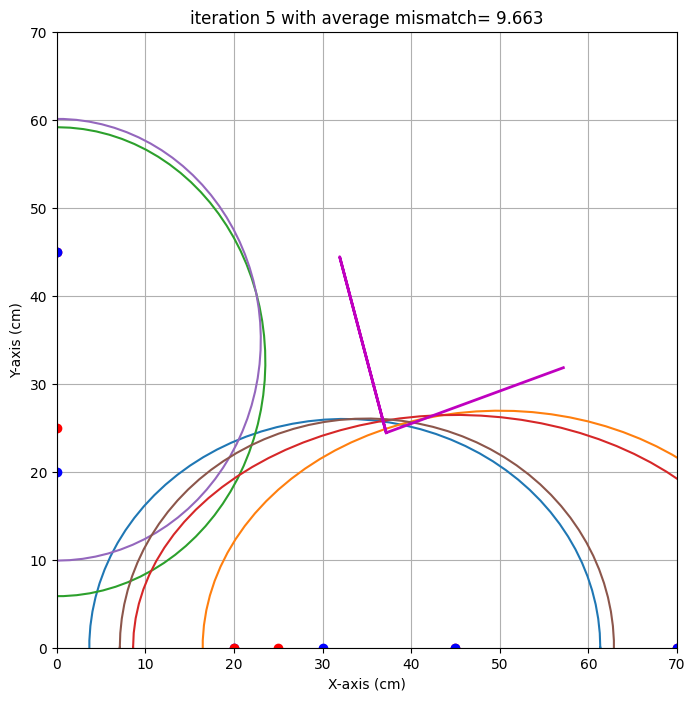

end iteration 5 with average mismatch= 9.663


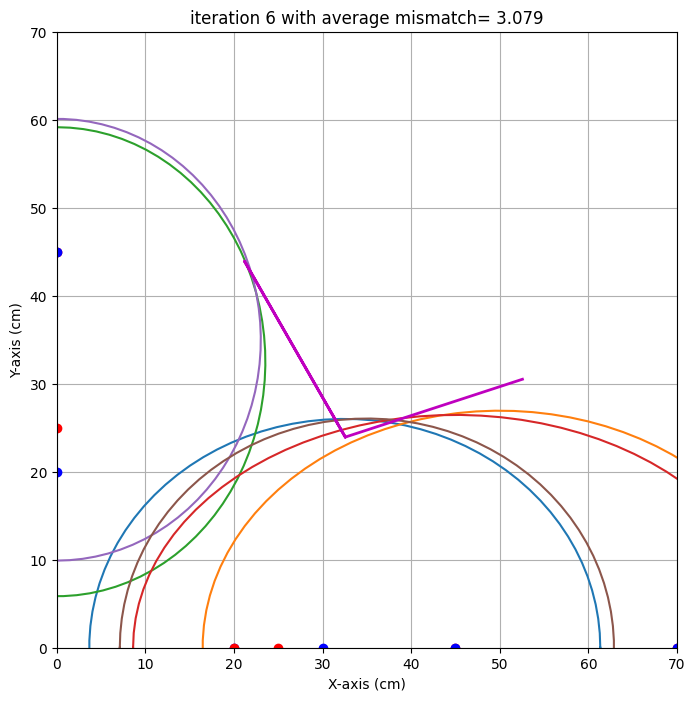

end iteration 6 with average mismatch= 3.079


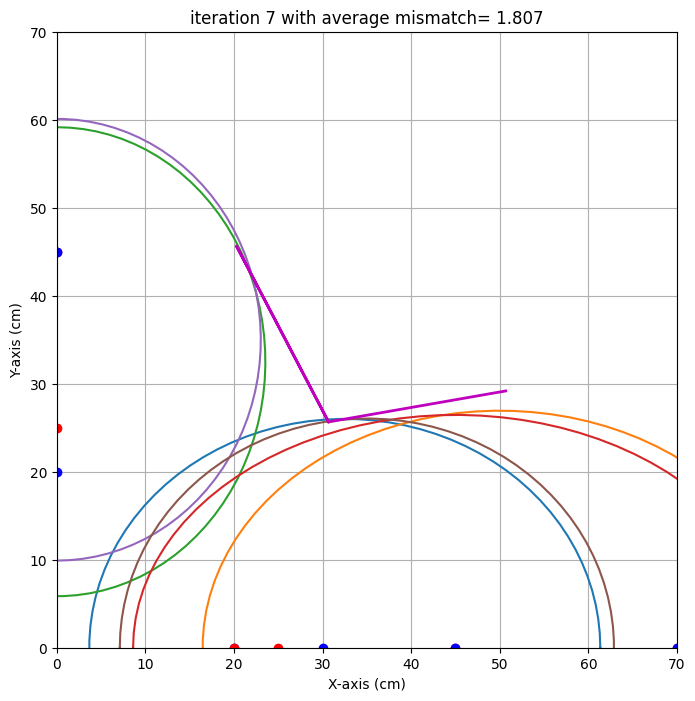

end iteration 7 with average mismatch= 1.807


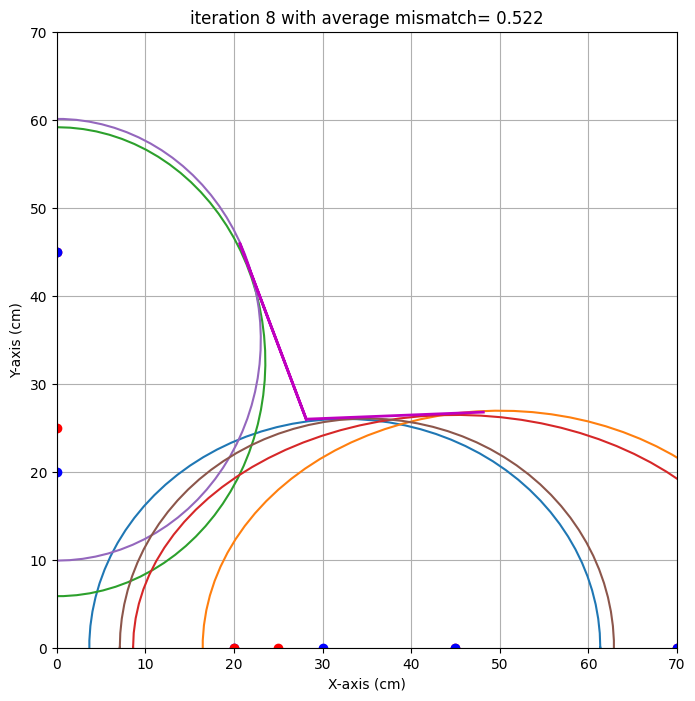

end iteration 8 with average mismatch= 0.522


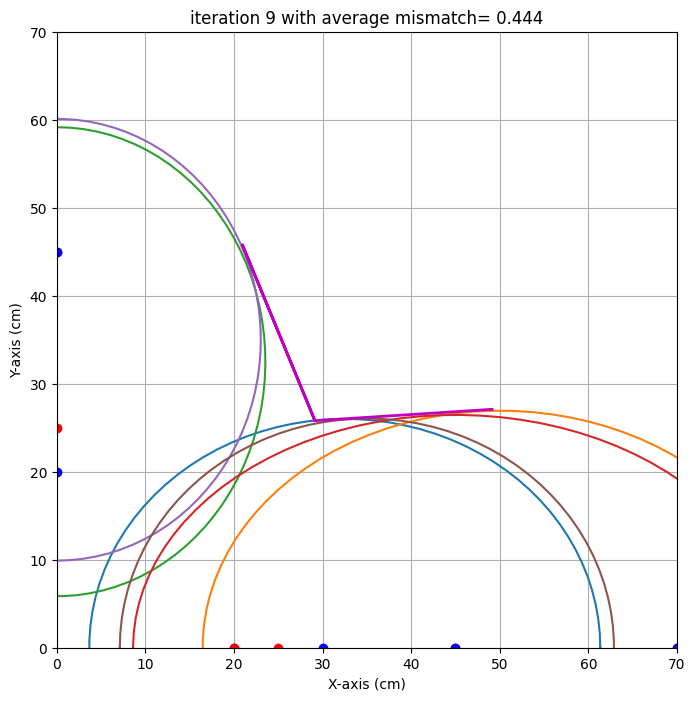

end iteration 9 with average mismatch= 0.444


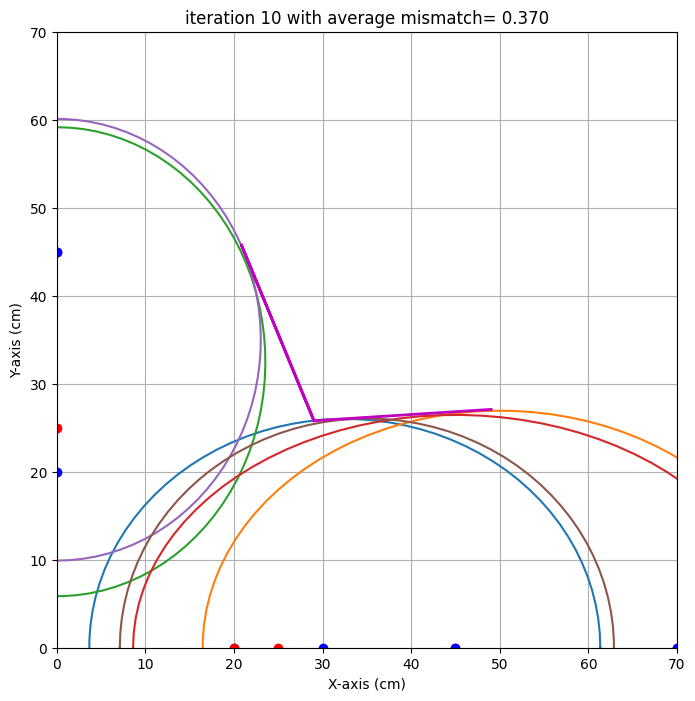

end iteration 10 with average mismatch= 0.370
end iteration 11 with average mismatch= 0.354
end iteration 12 with average mismatch= 0.346


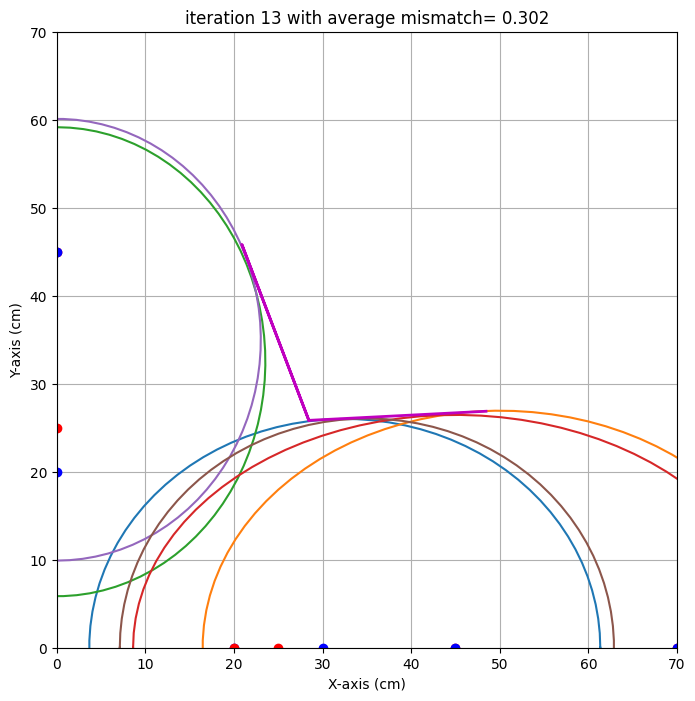

end iteration 13 with average mismatch= 0.302


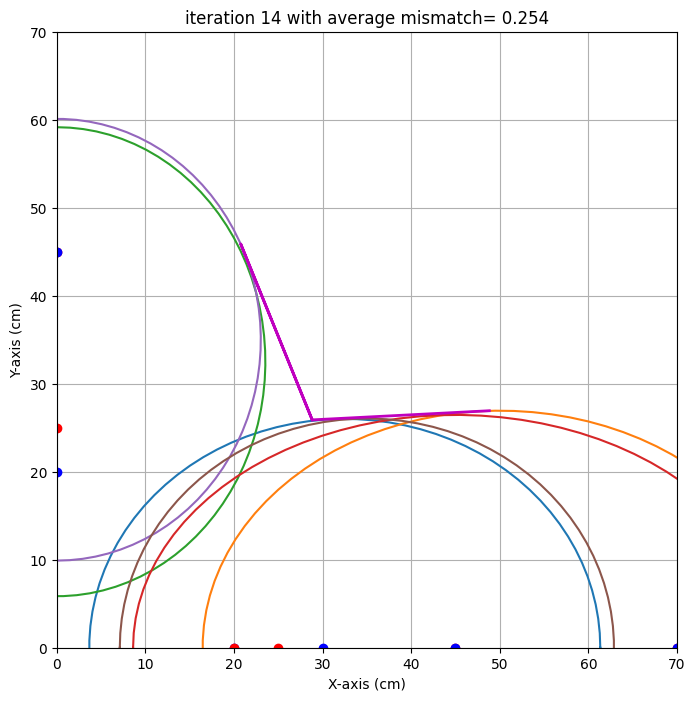

end iteration 14 with average mismatch= 0.254
end iteration 15 with average mismatch= 0.254
end iteration 16 with average mismatch= 0.254
end iteration 17 with average mismatch= 0.254
end iteration 18 with average mismatch= 0.254
end iteration 19 with average mismatch= 0.254
end iteration 20 with average mismatch= 0.254
end iteration 21 with average mismatch= 0.254
end iteration 22 with average mismatch= 0.254
end iteration 23 with average mismatch= 0.254
end iteration 24 with average mismatch= 0.254
end iteration 25 with average mismatch= 0.254
end iteration 26 with average mismatch= 0.254
end iteration 27 with average mismatch= 0.254
end iteration 28 with average mismatch= 0.254
end iteration 29 with average mismatch= 0.254
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.254
###############################################################################
end of iteration  30
Best alp

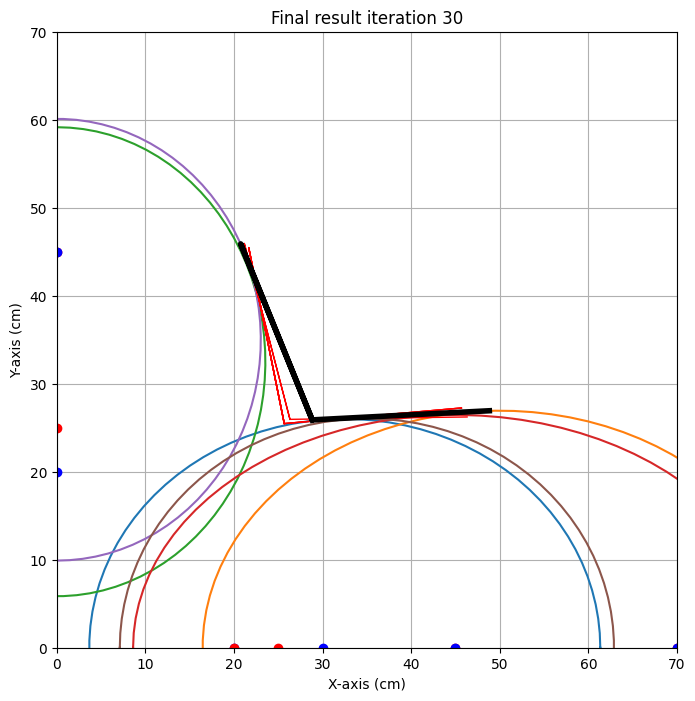

{'alpha': np.float64(2.970975768959732), 'alpha_eps': np.float64(2.199180842155522), 'beta': np.float64(-21.98531378674842), 'beta_eps': np.float64(10.633769911493133), 'x0': np.float64(28.823449071133986), 'x0_eps': np.float64(3.15354955610254), 'y0': np.float64(25.890406788930537), 'y0_eps': np.float64(0.4199065149879111)}
test locatie 
x0 target is : 26.0. Gevonden waarde: 28.8 cm met een standaardafwijking van 3.2 cm 
y0 target is : 25.0. Gevonden waarde: 25.9 cm met een standaardafwijking van 0.4 cm 
alpha target is : 1.0. Gevonden waarde: 3.0 graden met een standaardafwijking van 2.2 graad 
beta target is : -13.0. Gevonden waarde: -22.0 graden met een standaardafwijking van 10.6 graad 



In [13]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  26,
                    'y0':  25,
                    'alpha' : 1,
                    'beta' : -13
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [45, 0, 20, 0, 57.7],
                    #[45, 0, 70, 0, -],
                    [70, 0, 30, 0, 67.1],
                    [0, 45, 0, 20, 53.3],
                    #[0, 45, 0, 70, -],
                    #[0, 70, 0, 30, -]
                    [20, 0, 70, 0, 72.8],
                    #[0, 70, 0, 20, -]
                    [0, 25, 0, 45, 50.2],
                    #,
                    #[0, 50, 0, 65, -],
                    [25, 0, 45, 0, 55.8],
                    #[50, 0, 65, 0, -]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.

## Iteratie 0: onze individuele blokschema's (13:40)
Figuur: ![Alt](Iteratie0Frank.jpeg "Iteratie 0 van Frank")

Figuur: ![Alt](iteratie0Kimi.jpeg "Iteratie 0 van Kimi")

Bij onze individuele iteraties hebben we allebei gebruikgemaakt van een methode om eerst te kaderen waar het punt van het scherm ongeveer zit. Vervolgens voeren we meerdere metingen uit op basis van de verwachte plek van het scherm. Bij Frank is het veld verdeeld in kwadranten, en bij Kimi in octanten.

Bij Frank was het probleem dat de er te weinig ellipsen gemeten werden om een accurate resolutie te verkrijgen, waardoor het enkel zichtbaar werd in welk kwadrant het flapje zich bevond, zonder dat er bepaald werd waar de hoek zich bevond.

Bij Kimi bleek dat de manier van lokalisatie in de octanten niet helemaal werkte. Ook klopte de metingcombinaties per octant niet, want daar werd niet rekening gehouden met kleine hoeken.

## Iteratie 1: gecombineerd blokschema (14:20)

Figuur: ![Alt](Iteratie1.jpeg "gezamenlijk blokschema")

Het bleek dat het lokaliseren in octanten/kwadranten niet de beste aanpak was, vooral niet wanneer de hoek ook moet kunnen fluctueren. We hebben daarom voor iteratie 1 een hele andere aanpak gebruikt. We starten de meting op een bepaald punt, en als deze geen bruikbare waarde geeft, dan weten we iets over de positie dan verschuiven we de zender/ontvanger naar een andere plek. Dit doen we voor zowel de x als y kant.


## Iteratie 2: verbeterd met meer metingen (15:00)

Figuur: ![Alt](iteratie2.jpeg "gezamenlijk blokschema")

De metingen bleken niet heel goed uit te komen met het vorige algoritme, maar de werking was er wel. Daarom hebben we voor de laatste iteratie wat meer meetpunten toegevoegd, waar de zender en ontvanger ook dichterbij elkaar liggen. Dan kan de hoek beter bepaald worden.
